# DNAI

<div style="
    background-color: #e7f3ff;
    border-left:6px solid #2196f3;
    padding:12px;
    border-radius:4px;
    font-family: sans-serif;
">
<strong>⚠️ Warning</strong><br>
This notebook assumes the project environment is installed.
Run:
<pre><code>import sys
!"{sys.executable}" -m pip install -e ..</code></pre>
Restart the kernel before continuing.
</div>

In [1]:
# import sys
# !"{sys.executable}" -m pip install -e ..

* Load modules and directories

In [215]:
from DNAI.utils.paths import PROJECT_ROOT, DATA_RAW_DIR, RESULTS_DIR, RESULTS_FIGURES_DIR, RESULTS_TABLES_DIR
from DNAI.features import engineering 
from DNAI.features import text_analysis

import krippendorff
from scipy.stats import chi2_contingency

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## ETL

### Analysts

In [2]:
df_analysts = pd.read_excel(f'{DATA_RAW_DIR}/Dados Analistas/Analistas - Empilhada - Tratada e Limpa V02.xlsx', sheet_name='Dados Empilhados')

* Separate data for the two analysts

In [3]:
df_analysts_sv = df_analysts[df_analysts['A.01b - Analista'] == 'SV'].copy()
df_analysts_vs = df_analysts[df_analysts['A.01b - Analista'] == 'VS'].copy()

1. Duplicate and missing data detection

In [4]:
for (analyst, df) in [('SV',df_analysts_sv), ('VS',df_analysts_vs)]:
    print(f'Duplicated {analyst} : {df['ID e Nome do Filme'].duplicated().sum()}')
    print(f'Missing {analyst} : {df['ID e Nome do Filme'].isna().sum()}')

Duplicated SV : 0
Missing SV : 0
Duplicated VS : 0
Missing VS : 0


2. Film ID extraction

In [5]:
column = 'ID Filme Novo'

df_analysts_sv['film_id'] = df_analysts_sv[column]
df_analysts_vs['film_id'] = df_analysts_vs[column]

<div style="
    background-color: #77b6e9ff;
    border-left:6px solid #77b6e9ff;
    padding:12px;
    border-radius:4px;
    font-family: sans-serif;
">
<strong>Note</strong><br>
Films that are below ID 1069000 are removed from analysis
</div>

In [6]:
df_analysts_sv = df_analysts_sv[df_analysts_sv['film_id'] > 1069000]
df_analysts_vs = df_analysts_vs[df_analysts_vs['film_id'] > 1069000]

### Authors and Peers

In [ ]:
df_authors_peers = pd.read_excel(f'{DATA_RAW_DIR}/Dados Autores e Pares/Empilhado_SVVS Partes 1 e 2 Empilhado - regular.xlsx')

1. Film ID extraction

In [8]:
df_authors_peers['film_id'] = df_authors_peers['ID Filme']

<div style="
    background-color: #77b6e9ff;
    border-left:6px solid #77b6e9ff;
    padding:12px;
    border-radius:4px;
    font-family: sans-serif;
">
<strong>Note</strong><br>
Films that are below ID 1069000 are removed from analysis
</div>

In [9]:
df_authors_peers = df_authors_peers[df_authors_peers['film_id'] > 1069000]

### AI

#### ChatGPT

In [10]:
df_ai_chatgpt = pd.read_excel(f'{DATA_RAW_DIR}/Dados IA/AN-IA - SV_ChatGPT_ Formulário de simulação de análise e categorização de filmes por IA (respostas).xlsx')

1. Duplicate and missing data removal

In [11]:
column = 'D.01 - Qual o filme referente a esta análise simulada de IA?'

df_ai_chatgpt.drop_duplicates(subset=column, keep='first', inplace=True)
df_ai_chatgpt.dropna(subset=column, inplace=True)

2. Film ID extraction

In [12]:
df_ai_chatgpt['film_id'] = df_ai_chatgpt[column].str.extract(r"\)\s*(.*?)\s*-").astype(int)

<div style="
    background-color: #77b6e9ff;
    border-left:6px solid #77b6e9ff;
    padding:12px;
    border-radius:4px;
    font-family: sans-serif;
">
<strong>Note</strong><br>
Films that are below ID 1069000 are removed from analysis
</div>

In [13]:
df_ai_chatgpt = df_ai_chatgpt[df_ai_chatgpt['film_id'] > 1069000]

#### Gemini

In [14]:
df_ai_gemini = pd.read_excel(f'{DATA_RAW_DIR}/Dados IA/AN-IA - VS_Gemini_ Formulário de simulação de análise e categorização de filmes por IA (respostas) (1).xlsx')

1. Duplicate and missing data removal

In [15]:
column = 'D.01 - Qual o filme referente a esta análise simulada de IA?'

df_ai_gemini.drop_duplicates(subset=column, keep='first', inplace=True)
df_ai_gemini.dropna(subset=column, inplace=True)

2. Film ID extraction

In [16]:
df_ai_gemini['film_id'] = df_ai_gemini['D.01 - Qual o filme referente a esta análise simulada de IA?'].str.extract(r"\)\s*(.*?)\s*-").astype(int)

<div style="
    background-color: #77b6e9ff;
    border-left:6px solid #77b6e9ff;
    padding:12px;
    border-radius:4px;
    font-family: sans-serif;
">
<strong>Note</strong><br>
Films that are below ID 1069000 are removed from analysis
</div>

In [17]:
df_ai_gemini = df_ai_gemini[df_ai_gemini['film_id'] > 1069000]

#### Semantic and lexical richness

* Lexical richness is used based on the "Measure of Textual Lexical Diversity (MTLD)" metric.
* Semantic richness is used based on the "Mean pairwise distance between sentence embeddings", which is obtained using embeddings of topics using the "paraphrase-multilingual-MiniLM-L12-v2" model from sentence transformers. After embedding, the pairwise cosine distances are calculated into a distance matrix, and the mean value of the off-diagonal values is returned. 

In [18]:
col_title = 'D.01 - Qual o filme referente a esta análise simulada de IA?'
col_transcript = 'E.0b) Insira aqui a Transcrição do filme a ser processado'

file_path =f'{RESULTS_DIR}/df_transcripts_richness.csv'

def get_text_richness(row):

    transcript = row[f'{col_transcript}_ChatGPT']

    if isinstance(transcript, float):
        return np.nan, np.nan

    _clean_transcript = text_analysis.clean_transcript(transcript)

    try:
        lexical = text_analysis.lexical_richness(_clean_transcript)
    except:
        lexical = np.nan
    try:
        semantic = text_analysis.semantic_richness(_clean_transcript)
    except ValueError:
        semantic = np.nan

    return lexical, semantic

if not os.path.exists(file_path):
    df_transcripts = pd.merge(df_ai_chatgpt[[col_title, col_transcript]], df_ai_gemini[[col_title, col_transcript]], on = col_title, how='outer', suffixes=('_ChatGPT', '_Gemini'))

    df_transcripts[['lexical_richness', 'semantic_richness']] = df_transcripts.apply(get_text_richness, axis = 1, result_type='expand')

    df_transcripts.to_csv(file_path)
else:
    df_transcripts = pd.read_csv(file_path, index_col = 0)

In [19]:
df_transcripts['film_id'] = df_transcripts[col_title].str.extract(r"\)\s*(.*?)\s*-").astype(int)
df_transcripts.set_index('film_id', inplace=True)


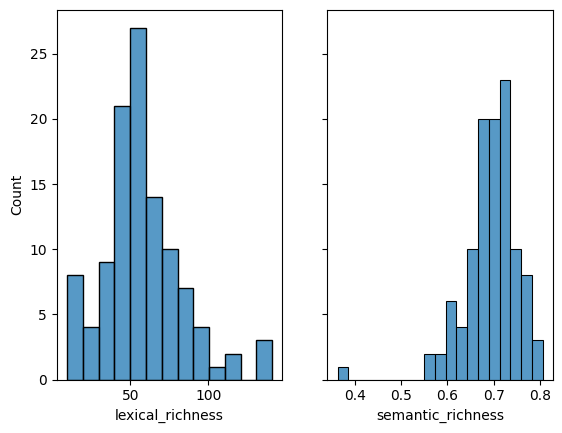

In [20]:
fig, axes = plt.subplots(1,2, sharey=True)
richness = ['lexical_richness', 'semantic_richness']

for ax, r in zip(axes, richness):
    sns.histplot(df_transcripts, x=r, ax=ax)

plt.show()

## Micro Level Analysis

* Micro level analysis is based on semantic similarity between descriptions of films made by the agents. The semantic similarity is calculated using the "paraphrase-multilingual-MiniLM-L12-v2" model from setence-transformers, where embeddings of texts are made and the cosine similarity is calculated. 

### Analysts

In [21]:
columns = ['B.02 - Em uma frase (poucas palavras, suas) sobre o que é o filme analisado? [procure não se ater somente ao título ou sinopse]',
           'B.03 - Qual o tema ou temas que este filme mobilizam?\n[resposta espontânea e aberta de quem analisa]']

df_sv = df_analysts_sv[['film_id'] + columns].copy()
df_vs = df_analysts_vs[['film_id'] + columns].copy()

df_sv['micro'] = df_sv[columns[0]] + '\n' + df_sv[columns[1]]
df_vs['micro'] = df_vs[columns[0]] + '\n' + df_vs[columns[1]]

df_micro_analysts = pd.merge(df_sv[['film_id', 'micro']], df_vs[['film_id', 'micro']], on='film_id', suffixes=('_SV','_VS'))
df_micro_analysts.set_index('film_id', inplace = True)


* Computation of semantic similarity betweem micro descriptions of films by the two analysts

In [22]:
label_a, label_b = ('micro_SV','micro_VS')
df_micro_analysts['similarity'] = df_micro_analysts.apply(lambda row : text_analysis.semantic_similarity(row, label_a, label_b), axis = 1)

In [23]:
df_micro_analysts['similarity_lemma'] = df_micro_analysts.apply(lambda row : text_analysis.semantic_similarity(row, label_a, label_b, lemma=True), axis = 1)

### AI

In [24]:
column = 'E.2) Insira aqui a resposta da IA com os dados da análise simulada [por favor, revise antes de enviar]:'

df_chatgpt = df_ai_chatgpt.copy()
df_gemini = df_ai_gemini.copy()

df_chatgpt['micro'] = df_chatgpt[column].str.replace(r"[^A-Za-zÀ-ÖØ-öø-ÿ]+", " ", regex=True).str.strip()
df_gemini['micro'] = df_gemini[column].str.replace(r"[^A-Za-zÀ-ÖØ-öø-ÿ]+", " ", regex=True).str.strip()

df_micro_ai = pd.merge(df_chatgpt[['film_id', 'micro']], df_gemini[['film_id', 'micro']], on = 'film_id', suffixes=('_ChatGPT', '_Gemini'))
df_micro_ai.set_index('film_id', inplace=True)

* Computation of semantic similarity betweem micro descriptions of films by the two AIs

In [25]:
label_a, label_b = ('micro_ChatGPT', 'micro_Gemini')

df_micro_ai['similarity'] = df_micro_ai.apply(lambda row : text_analysis.semantic_similarity(row, label_a, label_b), axis = 1)

In [26]:
df_micro_ai['similarity_lemma'] = df_micro_ai.apply(lambda row : text_analysis.semantic_similarity(row, label_a, label_b, lemma=True), axis = 1)

### Authors and peers

* Note: For micro analysis, only data curated by one of the analysts is required

In [27]:
df_authors_peers_micro = df_authors_peers[df_authors_peers['Analista'] == 'VS']

df_authors_micro = df_authors_peers_micro[df_authors_peers_micro['Tipo de Participação autores ou pares'] == 'Participou'].copy()
df_peers_micro = df_authors_peers_micro[df_authors_peers_micro['Tipo de Participação autores ou pares'] == 'Não Participou'].copy()

In [28]:
columns = ['2013a_Em uma ou duas palavras é um filme sobre...:','2009_Como você resumiria este filme? (em poucas palavras)']

df_authors_micro['micro'] = df_authors_micro[columns[0]] + '\n' + df_authors_micro[columns[1]]
df_peers_micro['micro'] = df_peers_micro[columns[0]] + '\n' + df_peers_micro[columns[1]]

In [29]:
df_authors_micro['rater_index'] = df_authors_micro.groupby('film_id').cumcount().add(1).astype(str).radd('author_')
df_peers_micro['rater_index'] = df_peers_micro.groupby('film_id').cumcount().add(1).astype(str).radd('peer_')

df_authors_micro_wide = df_authors_micro.pivot(index='film_id', columns='rater_index', values='micro')
df_peers_micro_wide = df_peers_micro.pivot(index='film_id', columns='rater_index', values='micro')

* Computation of semantic similarity betweem micro descriptions of films by the all authors. The function text_analysis.semantic_similarity_intra compares all pairwise similarities between authors or peers and returns the maximum similarity value.

In [30]:
labels = df_authors_micro_wide.columns

df_micro_authors = pd.DataFrame()
df_micro_authors['similarity'] = df_authors_micro_wide.apply(lambda row : text_analysis.semantic_similarity_intra(row, labels), axis = 1)

In [31]:
df_micro_authors['similarity_lemma'] = df_authors_micro_wide.apply(lambda row : text_analysis.semantic_similarity_intra(row, labels, lemma=True), axis = 1)

In [32]:
labels = df_peers_micro_wide.columns

df_micro_peers = pd.DataFrame()
df_micro_peers['similarity'] = df_peers_micro_wide.apply(lambda row : text_analysis.semantic_similarity_intra(row, labels), axis = 1)

In [33]:
df_micro_peers['similarity_lemma'] = df_peers_micro_wide.apply(lambda row : text_analysis.semantic_similarity_intra(row, labels, lemma=True), axis = 1)

### Comparisons intra dimensions

In [34]:
colors_single = ['#D32F2F', '#FBC02D', '#26C6DA', '#135CAD']

* This section provides a description of how semantic similarities are distributed for each of the dimensions.

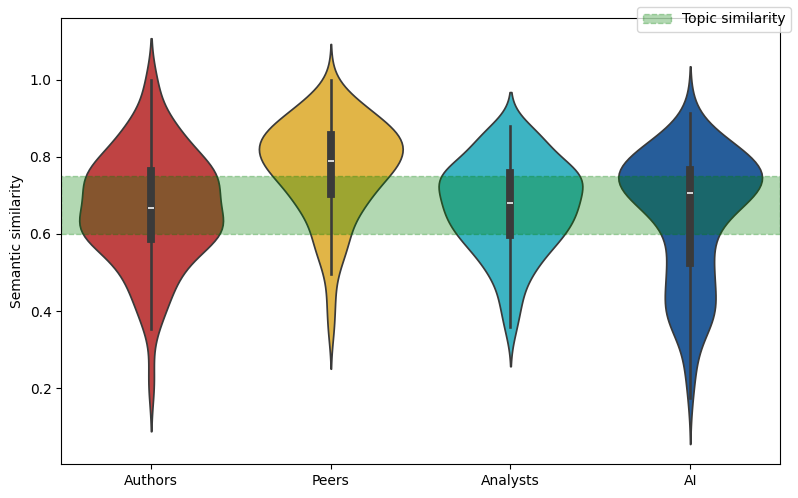

In [35]:
topic_low = 0.60
topic_high = 0.75

dfs_micro = {'Authors' : df_micro_authors, 'Peers' : df_micro_peers, 'Analysts' : df_micro_analysts, 'AI' : df_micro_ai}

df_micro_all = pd.concat([df['similarity'] for df in dfs_micro.values()], axis = 1)
df_micro_all.columns=dfs_micro.keys()

fig, ax = plt.subplots(1,1, figsize=(8,5))
sns.violinplot(df_micro_all, ax = ax, palette=colors_single)
ax.set_ylabel('Semantic similarity')
ax.axhspan(topic_low, topic_high, color = 'green', linestyle='--', label = 'Topic similarity', alpha = 0.3)

fig.legend()
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/micro_single_max.png', dpi = 300)
plt.show()

df_micro_all.to_excel(f'{RESULTS_TABLES_DIR}/micro_single_max.xlsx')

Result : All dimensions report high semantic similarity, with averages located within topic similarity range. This indicates that for each dimension, the agents agree on the contents of the films in general.

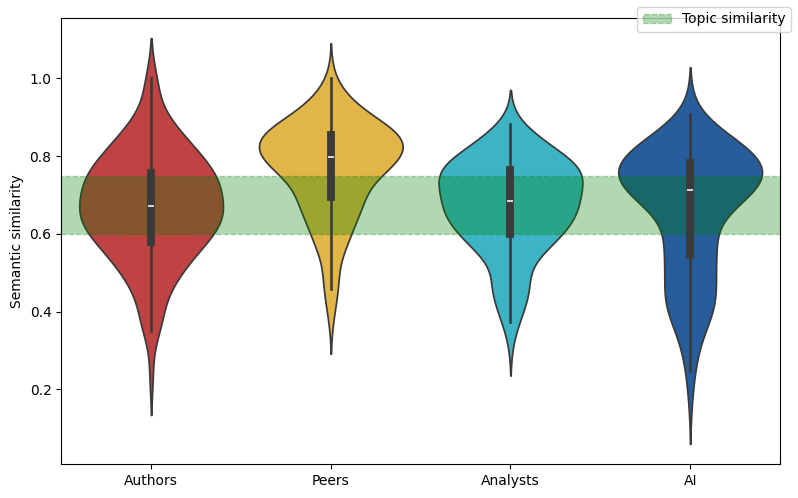

In [36]:
df_micro_all_lemma = pd.concat([df['similarity_lemma'] for df in dfs_micro.values()], axis = 1)
df_micro_all_lemma.columns=dfs_micro.keys()

fig, ax = plt.subplots(1,1, figsize=(8,5))
sns.violinplot(df_micro_all_lemma, ax = ax, palette=colors_single)
ax.set_ylabel('Semantic similarity')
ax.axhspan(topic_low, topic_high, color = 'green', linestyle='--', label = 'Topic similarity', alpha = 0.3)

fig.legend()
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/micro_single_lemma_max.png', dpi = 300)
plt.show()

df_micro_all_lemma.to_excel(f'{RESULTS_TABLES_DIR}/micro_single_lemma_max.xlsx')

### Comparisons inter dimensions

In [37]:
colors_combinations = ['#1290D0', '#C15278', '#7EE0A3', '#8E45E5', '#3B855B', '#F57F17']

In [38]:
labels = {'Analysts' : ['micro_VS', 'micro_SV'],
          'AI' : ['micro_ChatGPT', 'micro_Gemini'],
          'Authors' : df_authors_micro_wide.columns,
          'Peers' : df_peers_micro_wide.columns}

dfs_micro_all = {'Analysts' : df_micro_analysts,
       'AI' : df_micro_ai,
       'Authors' : df_authors_micro_wide,
       'Peers' : df_peers_micro_wide}


In [39]:
from itertools import combinations 
import warnings

file_path = f'{RESULTS_DIR}/df_micro_comparisons.csv'

if not os.path.exists(file_path):

    dimension_comparisons = list(combinations(labels.keys(), 2))

    list_dfs = []

    for combination in dimension_comparisons:

        dimension_a, dimension_b = combination

        labels_a = labels[dimension_a]
        labels_b = labels[dimension_b]

        df_merge = pd.merge(dfs_micro_all[dimension_a], dfs_micro_all[dimension_b], on = 'film_id', how ='outer')
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", FutureWarning)
            df_merge[f'{dimension_a} and {dimension_b}'] = df_merge.apply(lambda row: text_analysis.semantic_similarity_inter(row, labels_a, labels_b), axis = 1)
        
        list_dfs.append(df_merge[f'{dimension_a} and {dimension_b}'])

    df_micro_comparisons = pd.concat(list_dfs, axis = 1, join='outer')
    df_micro_comparisons.to_csv(file_path)

else:
    df_micro_comparisons = pd.read_csv(file_path, index_col=0)

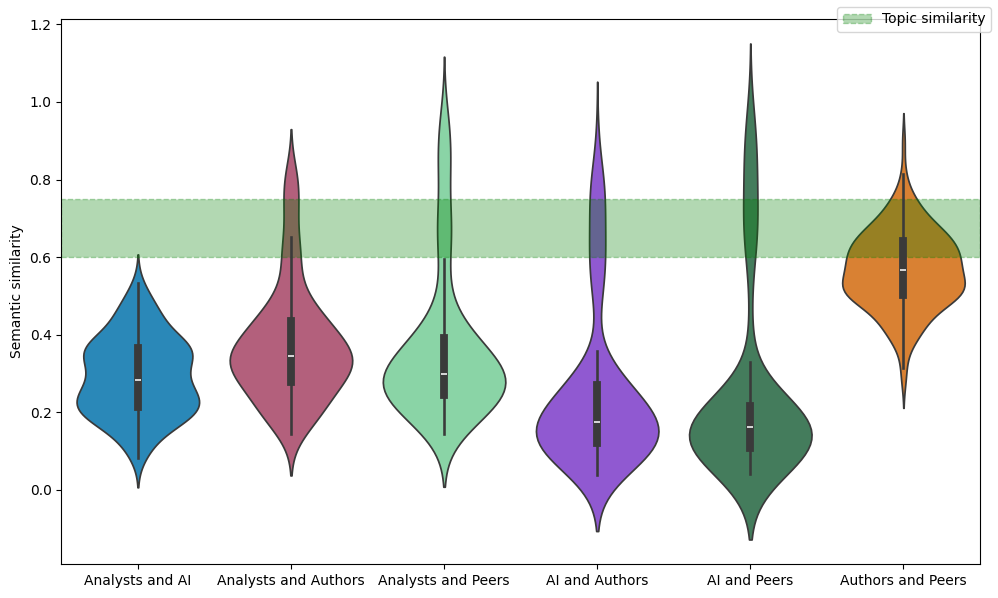

In [40]:
fig, ax = plt.subplots(1,1, figsize=(10,6))

sns.violinplot(data=df_micro_comparisons, ax = ax, palette=colors_combinations)
ax.set_ylabel('Semantic similarity')
ax.axhspan(topic_low, topic_high, color = 'green', linestyle='--', label = 'Topic similarity', alpha = 0.3)

fig.legend()
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/micro_multi_all.png', dpi = 300)
plt.show()

df_micro_comparisons.to_excel(f'{RESULTS_TABLES_DIR}/micro_multi_all.xlsx')

In [41]:
file_path = f'{RESULTS_DIR}/df_micro_comparisons_lemma.csv'

if not os.path.exists(file_path):

    dimension_comparisons = list(combinations(labels.keys(), 2))

    list_dfs = []

    for combination in dimension_comparisons:

        dimension_a, dimension_b = combination

        labels_a = labels[dimension_a]
        labels_b = labels[dimension_b]

        df_merge = pd.merge(dfs_micro_all[dimension_a], dfs_micro_all[dimension_b], on = 'film_id', how ='outer')
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", FutureWarning)
            df_merge[f'{dimension_a} and {dimension_b}'] = df_merge.apply(lambda row: engineering.semantic_similarity_inter(row, labels_a, labels_b, lemma=True), axis = 1)
        
        list_dfs.append(df_merge[f'{dimension_a} and {dimension_b}'])

    df_micro_comparisons_lemma = pd.concat(list_dfs, axis = 1, join='outer')
    df_micro_comparisons_lemma.to_csv(file_path)

else:
    df_micro_comparisons_lemma = pd.read_csv(file_path, index_col=0)

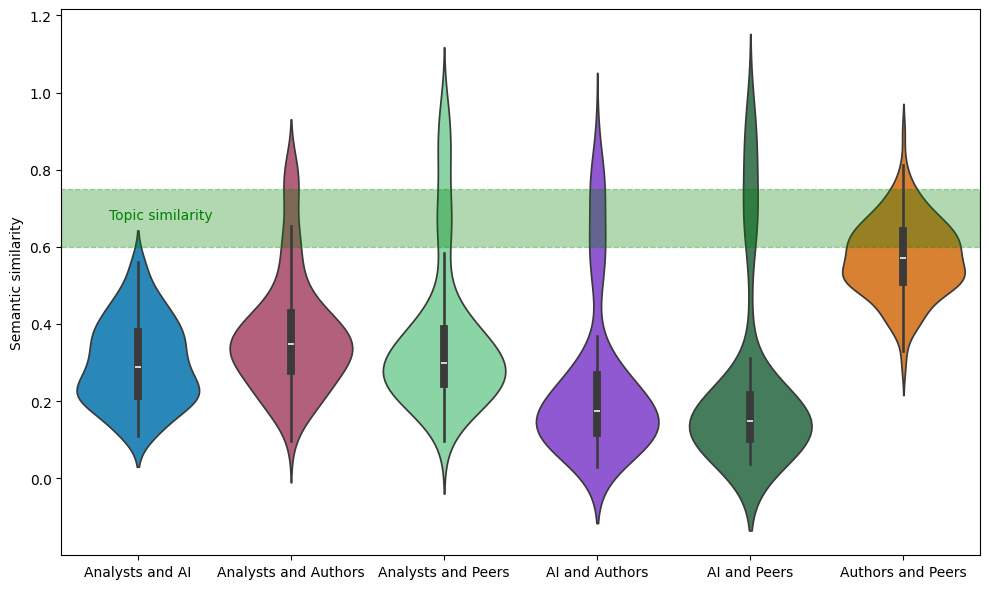

In [42]:
fig, ax = plt.subplots(1,1, figsize=(10,6))

sns.violinplot(data=df_micro_comparisons_lemma, ax = ax, palette=colors_combinations)
ax.set_ylabel('Semantic similarity')
ax.axhspan(topic_low, topic_high, color = 'green', linestyle='--', label = 'Topic similarity', alpha = 0.3)
ax.text(0.15,
    0.7,
    "Topic similarity",
    ha="center",
    va="top",
    color="green",
    fontsize=10,
)

fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/micro_multi_all_lemma.png', dpi = 300)
plt.show()

df_micro_comparisons_lemma.to_excel(f'{RESULTS_TABLES_DIR}/micro_multi_all_lemma.xlsx')

### Comparison between text richness and micro level 

* In this section, the semantic similarity is plotted against the semantic or lexical richness of texts. A linear fit is attempted, to check if there is a correlation between these two properties across all films. The mean word count is also calculated to see if it has an effect on both these two properties.

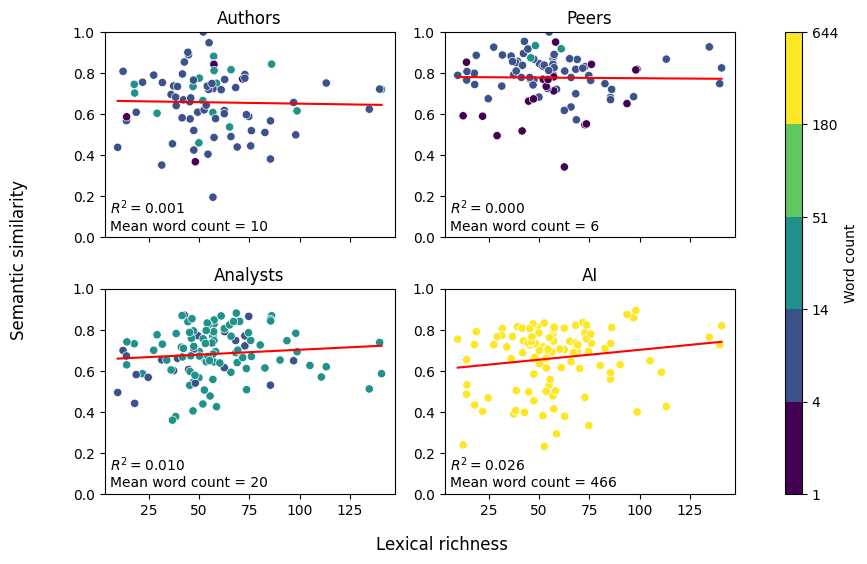

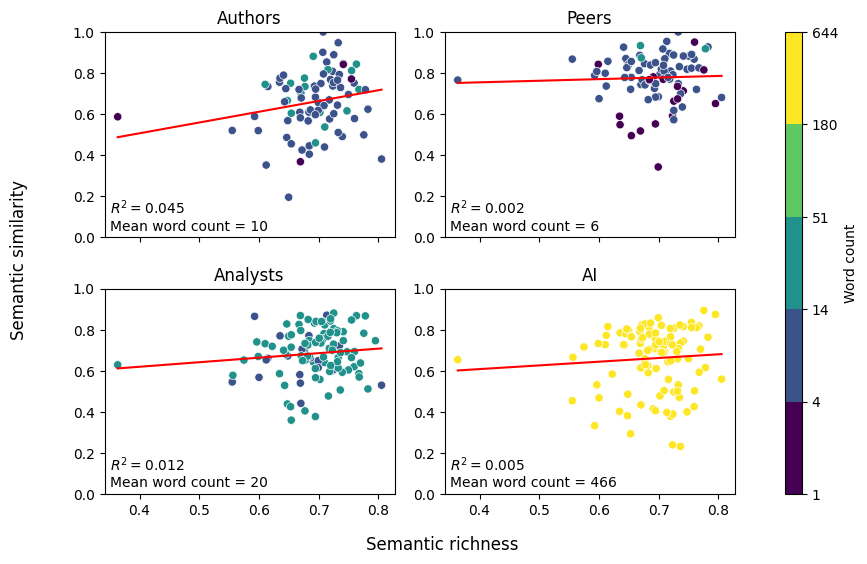

In [43]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable

labels = [1,2,3,4,5]

word_counts = []

for dimension, df in dfs_micro_all.items():
    df_word_count = df.map(lambda x: len(str(x).split()))
    mean = df_word_count.mean(axis=1)
    mean.name = dimension + '_N'
    word_counts.append(mean)

df_word_counts = pd.concat(word_counts, axis = 1)

bins = np.logspace(np.log10(df_word_counts.min().min()),
                   np.log10(df_word_counts.max().max()),
                   6)

def bin_value(x):
    return pd.cut([x], bins=bins, labels=labels, include_lowest=True)[0]

df_bins = df_word_counts.map(bin_value)

cmap_word = ListedColormap(plt.cm.viridis(np.linspace(0, 1, len(labels))))
norm_word = BoundaryNorm(bins, cmap_word.N)
palette = {label: cmap_word(i) for i, label in enumerate(labels)}

for richness in ['lexical_richness', 'semantic_richness']:
    df = pd.concat([df_micro_all, df_transcripts[richness]], axis = 1)

    fig = plt.figure(figsize=(9, 6))
    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.06], height_ratios = [1,1], hspace=0.25, wspace=0.25)

    ax1 = fig.add_subplot(gs[0,0])
    ax2 = fig.add_subplot(gs[0,1], sharex=ax1)
    ax3 = fig.add_subplot(gs[1,0], sharex=ax1)
    ax4 = fig.add_subplot(gs[1,1], sharex=ax1)

    ax1.tick_params(labelbottom=False)
    ax2.tick_params(labelbottom=False)

    axes = [ax1,ax2,ax3,ax4]
    
    df_out_list = []
    for dimension, ax in zip(dfs_micro.keys(), axes):
        _df_color = df_bins[dimension + '_N']
        _df_color.name = dimension + '_color'
        _df_word_count = df_word_counts[dimension + '_N']
        _df = pd.concat([df[richness], df[dimension], _df_color, _df_word_count], axis = 1)
        
        sns.scatterplot(data=_df, 
                        x=richness, 
                        y=dimension, 
                        hue=f'{dimension}_color', 
                        hue_order=labels,
                        palette=palette,
                        ax=ax,
                        legend=False
                        )
        ax.set_ylabel('')
        ax.set_xlabel('')
        ax.set_ylim(0,1)
        ax.set_title(dimension)

        x_range, y_pred, r2 = engineering.get_fitted(df, richness, dimension)
        mean_word_count = df_word_counts[f'{dimension}_N'].mean()
        ax.plot(x_range, y_pred, color = 'red')
        ax.text(
                0.02, 0.02,
                f"$R^2 = {r2:.3f}$\nMean word count = {mean_word_count:.0f}",
                transform=ax.transAxes,
                fontsize=10,
                va='bottom',
                ha='left'
            )
        if dimension != 'Authors':
            _df = _df.drop(richness, axis = 1)
        df_out_list.append(_df)

    cax = fig.add_subplot(gs[:, 2])

    sm = ScalarMappable(norm=norm_word, cmap=cmap_word)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_ticks(bins)
    cbar.set_ticklabels([f"{b:.0f}" for b in bins])
    cbar.set_label("Word count")
    
    if richness == 'lexical_richness':
        label = 'Lexical richness'
    else:
        label = 'Semantic richness'

    fig.supxlabel(label)
    fig.supylabel('Semantic similarity')
    fig.savefig(f'{RESULTS_FIGURES_DIR}/micro_{richness}.png', dpi = 300)

    df_out = pd.concat(df_out_list, axis = 1)
    df_out.to_excel(f'{RESULTS_TABLES_DIR}/micro_{richness}.xlsx')
    
    plt.show()

### Micro level text richness

In [44]:
def get_text_richness_micro(row):

    row = row[~row.index.str.contains("similarity", case=False, na=False)]
    
    transcript = " ".join(row.dropna())

    if isinstance(transcript, float):
        return np.nan, np.nan

    _clean_transcript = text_analysis.clean_transcript(transcript)

    try:
        lexical = text_analysis.lexical_richness(_clean_transcript)
    except:
        lexical = np.nan
    try:
        semantic = text_analysis.semantic_richness(_clean_transcript)
    except ValueError:
        semantic = np.nan

    return lexical, semantic


file_path = f'{RESULTS_DIR}/df_micro_richness.csv'

if not os.path.exists(file_path):
    results = {}
    for dimension, df in dfs_micro_all.items():
        df_out = pd.DataFrame(index = df.index)
        df_out[['lexical_richness', 'semantic_richness']] = df.apply(get_text_richness_micro, axis = 1, result_type='expand')

        results[dimension] = df_out
    
    df_micro_richness = pd.concat({k : v for k,v in results.items()}, axis = 1)
    df_micro_richness = df_micro_richness.swaplevel(0,1, axis = 1)
    df_micro_richness = df_micro_richness.sort_index(axis = 1)
    df_micro_richness.to_csv(file_path)
else: 
    df_micro_richness = pd.read_csv(file_path, index_col=0, header=[0,1])

df_micro_richness = df_micro_richness.reindex(columns=['Authors', 'Peers', 'Analysts', 'AI'], level = 1)

In [45]:
df_micro_richness.to_excel(f'{RESULTS_TABLES_DIR}/micro_textual_richness.xlsx')

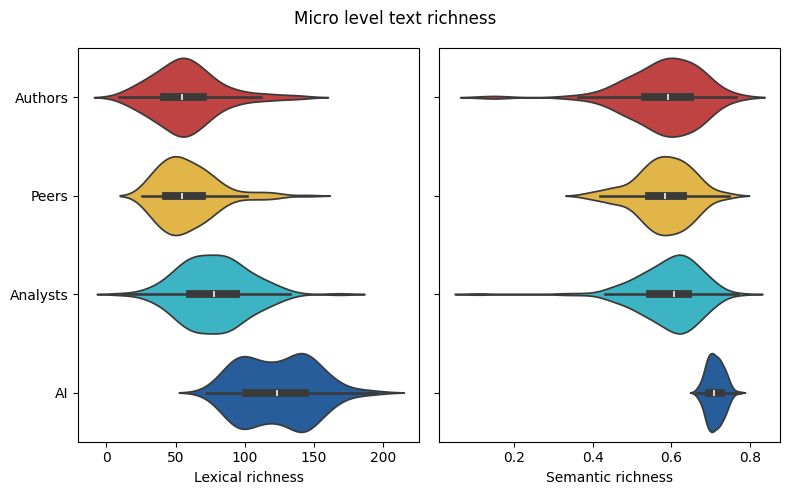

In [46]:
fig, axes = plt.subplots(1,2, sharey=True, figsize=(8,5))
for richness,ax in zip(['lexical_richness', 'semantic_richness'], axes):
    df = df_micro_richness.xs(richness, level=0, axis = 1)
    sns.violinplot(data=df, ax = ax, orient='h', palette=colors_single)
    
    if richness == 'semantic_richness':
        label = 'Semantic richness'
    else:
        label = 'Lexical richness'
    ax.set_xlabel(label)
fig.suptitle('Micro level text richness')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/micro_textual_richness.png', dpi = 300)

In [47]:
df_authors_micro_levels = df_authors_peers_micro[df_authors_peers_micro['Tipo de Participação autores ou pares'] == 'Participou'].copy()
df_authors_micro_levels['film_id'] = df_authors_micro_levels['ID Filme']



columns = ['2013a_Em uma ou duas palavras é um filme sobre...:','2009_Como você resumiria este filme? (em poucas palavras)']
column_author_level = 'Score de Participação autores ou pares de 0 a 5'

df_authors_micro_levels['micro'] = df_authors_micro[columns[0]] + '\n' + df_authors_micro[columns[1]]
df_authors_micro_levels['author_index'] = df_authors_micro_levels.groupby(['film_id', column_author_level]).cumcount()  + 1

df_authors_micro_levels_wide = df_authors_micro_levels.pivot(index='film_id', columns=[column_author_level,'author_index'], values='micro')
df_authors_micro_levels_wide.sort_index(axis=1, inplace= True)


In [48]:
def get_text_richness_micro_agent(transcript):
    
    if isinstance(transcript, float):
        return np.nan, np.nan

    _clean_transcript = text_analysis.clean_transcript(transcript)

    try:
        lexical = text_analysis.lexical_richness(_clean_transcript)
    except:
        lexical = np.nan
    try:
        semantic = text_analysis.semantic_richness(_clean_transcript)
    except ValueError:
        semantic = np.nan

    return lexical, semantic

_dfs_micro = {'Authors' : df_authors_micro_levels_wide, 
              'Peers' : df_peers_micro_wide, 
              'Analysts' : df_micro_analysts[['micro_SV','micro_VS']], 
              'AI' : df_micro_ai[['micro_ChatGPT','micro_Gemini']]}

dfs_micro_text_richness = {}
for dimension, df in _dfs_micro.items():

    file_path = f'{RESULTS_DIR}/df_micro_text_richness_{dimension}.csv'

    if not os.path.exists(file_path):

        df_out = pd.concat({col: df[col].map(get_text_richness_micro_agent).apply(pd.Series) for col in df.columns}, axis=1)
        df_out.rename(columns={0: "lexical_richness", 1: "semantic_richness"}, level=-1, inplace=True)
        df_out.columns = df_out.columns.set_names(df.columns.names + ['text_richness'])
        
        df_out.to_csv(file_path)
    else:
        if dimension == 'Authors':
            headers = [0,1,2]
        else:
            headers = [0,1]

        df_out = pd.read_csv(file_path, index_col=0, header = headers)    
    
    dfs_micro_text_richness[dimension] = df_out



In [49]:
colors_agents = ['#EF9A9A', '#E53935', '#B71C1C', '#FDD835', '#1FA7C5', '#0097A7', '#4C9FEA', '#1E88E5']

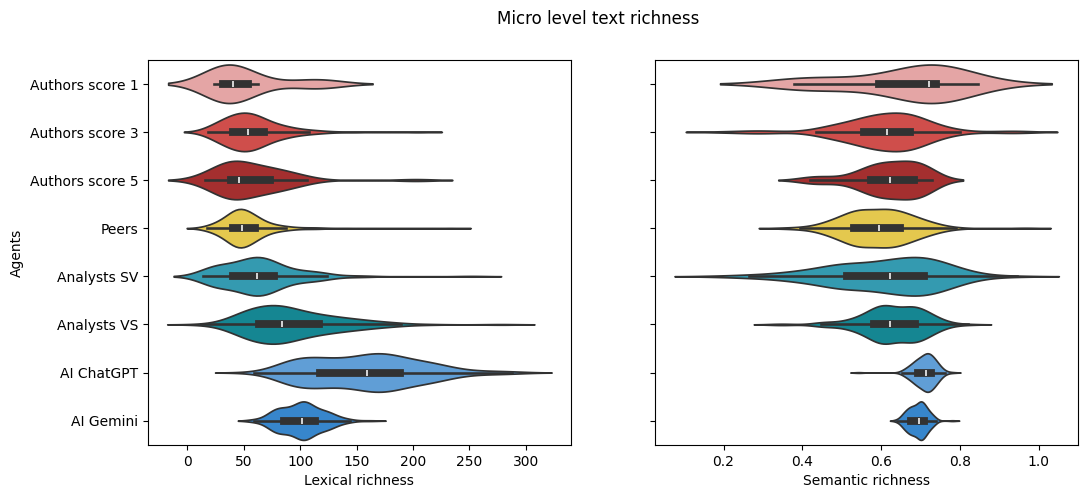

In [50]:
fig, axes = plt.subplots(1,2, sharey=True, figsize=(12,5))

for richness, ax in zip(['lexical_richness', 'semantic_richness'], axes):
    
    df_richness_list = []
    for dimension, df in dfs_micro_text_richness.items():
        df = df.xs(richness, level = -1, axis = 1)
        if dimension != 'Peers':
                
            df = df.T.groupby(level=0).mean().T

            if dimension == 'Authors':
                df.rename(columns = {col : f'{dimension} score {col}' for col in df.columns}, inplace=True)
            else:
                df.rename(columns = {col : f'{dimension} {col.replace('micro_', '')}' for col in df.columns}, inplace = True)
            
        else:
            df = df.T.groupby(level=0).mean().mean()
            df.name = dimension
        df_richness_list.append(df)

    df_richness = pd.concat(df_richness_list, axis = 1)

    sns.violinplot(data=df_richness, orient='h', ax = ax, palette=colors_agents)
    ax.set_ylabel('Agents')
    
    if richness == 'lexical_richness':
        label = 'Lexical richness'
    else:
        label = 'Semantic richness'
    ax.set_xlabel(label)

    df_richness.to_excel(f'{RESULTS_TABLES_DIR}/micro_{richness}_agents.xlsx')

fig.suptitle('Micro level text richness')
fig.savefig(f'{RESULTS_FIGURES_DIR}/micro_textual_richness_agents.png', dpi = 300)
plt.show()

## Meso Level Analysis

In [51]:
dfs_meso = {}
dfs_meso_agreements = {}
column_themes = ['Tema 0', 'Tema 2', 'Tema 3']

### Analysts

1. Theme extraction

In [52]:
for col in column_themes:

    df_analysts_sv[col] = df_analysts_sv[col].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()
    df_analysts_vs[col] = df_analysts_vs[col].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()

* Note: manual correction of categories

In [53]:
df_analysts_sv.set_index('film_id', inplace = True)
df_analysts_vs.set_index('film_id', inplace = True)

df_analysts_sv.loc[1080403, 'Tema 3'] = 'recreação, lazer e entretenimento'
df_analysts_sv.loc[1110215, 'Tema 3'] = 'solidão'

In [54]:
df_merge_analysts = pd.concat({'SV' : df_analysts_sv[column_themes], 'VS' : df_analysts_vs[column_themes]}, axis = 1)

#### IRR

In [55]:
alphas = []

df_num = engineering.cat_to_numeric(df_merge_analysts)

for col in column_themes:
    data = df_num.xs(col, level=1, axis = 1)

    alphas.append(krippendorff.alpha(reliability_data=data.T, level_of_measurement='nominal'))

dfs_meso['Analysts'] = pd.DataFrame(alphas, index=column_themes, columns=[r'Krippendorff $\alpha$'])

In [56]:
agreements = []

for col in column_themes:

    df = df_merge_analysts.xs(col, level = 1, axis = 1)

    agreement = df['VS'] == df['SV']

    agreements.append((agreement.sum() / len(df))*100)

dfs_meso_agreements['Analysts'] = pd.DataFrame(agreements, index = column_themes, columns=['Agreement ratio (%)'])

### AI

In [57]:
df_ai = pd.read_excel(f'{DATA_RAW_DIR}/Dados IA/AN-IAv3 - SVVS_ChatGPT-Gemini.xlsx')

In [58]:
df_ai['film_id'] = df_ai['IDFilme_NOVOID3']
#df_ai.set_index('film_id', inplace = True)

<div style="
    background-color: #77b6e9ff;
    border-left:6px solid #77b6e9ff;
    padding:12px;
    border-radius:4px;
    font-family: sans-serif;
">
<strong>Note</strong><br>
Films that are below ID 1069000 are removed from analysis
</div>

In [59]:
df_ai = df_ai[df_ai['film_id'] > 1069000]

1. Theme extraction

In [60]:
df_ai.rename(columns={'Tema 1' : 'Tema 0'}, inplace=True)

for col in column_themes:
    df_ai[col] = df_ai[col].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()

In [61]:
df_ai_gemini = df_ai[df_ai['NA (quem processou a IA)'] == 'VS'].copy()
df_ai_chatgpt = df_ai[df_ai['NA (quem processou a IA)'] == 'SV'].copy()

Note: Some films were passed through the AI more than once. Those are indentified below and then duplicates are removed, keeping only the last passage.

In [62]:
df_ai_chatgpt[df_ai_chatgpt['film_id'].duplicated(keep=False)].sort_values(by='film_id')[['film_id', 'Oficina','ID']]

,film_id,Oficina,ID
66,1080411,10804,4067
169,1080411,10804,4170
81,1090102,10901,4082
80,1090102,10901,4081
106,1110209,11102,4107
118,1110209,11102,4119


In [63]:
df_ai_gemini[df_ai_gemini['film_id'].duplicated(keep=False)].sort_values(by='film_id')[['film_id', 'Oficina','ID']]

,film_id,Oficina,ID
176,1070107,10701,5007
177,1070107,10701,5008
192,1080107,10801,5023
193,1080107,10801,5024
221,1080410,10804,5052
222,1080410,10804,5053


In [64]:
df_ai_chatgpt = df_ai_chatgpt.sort_values('ID').drop_duplicates(subset='film_id', keep = 'last').set_index('film_id')      
df_ai_gemini = df_ai_gemini.sort_values('ID').drop_duplicates(subset='film_id', keep = 'last').set_index('film_id')

df_merge_ai = pd.concat({'ChatGPT' : df_ai_chatgpt[column_themes], 'Gemini' : df_ai_gemini[column_themes]}, axis = 1)

#### IRR

In [65]:
alphas = []

df_num = engineering.cat_to_numeric(df_merge_ai)

for col in column_themes:
    data = df_num.xs(col, level=1, axis = 1)

    alphas.append(krippendorff.alpha(reliability_data=data.T, level_of_measurement='nominal'))

dfs_meso['AI'] = pd.DataFrame(alphas, index=column_themes, columns=[r'Krippendorff $\alpha$'])

In [66]:
agreements = []

for col in column_themes:

    df = df_merge_ai.xs(col, level = 1, axis = 1)

    agreement = df['ChatGPT'] == df['Gemini']

    agreements.append((agreement.sum() / len(df))*100)

dfs_meso_agreements['AI'] = pd.DataFrame(agreements, index = column_themes, columns=['Agreement ratio (%)'])

### Authors and Peers

In [68]:
df_authors_peers.set_index(['Analista','film_id'], inplace = True)

1. Theme extraction

In [70]:
for col in column_themes:
    
    df_authors_peers[col] = df_authors_peers[col].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()

In [71]:
column_status = 'Tipo de Participação autores ou pares'

df_authors = df_authors_peers[df_authors_peers[column_status] == 'Participou'].copy()
df_peers = df_authors_peers[df_authors_peers[column_status] == 'Não Participou'].copy()

df_authors_vs = df_authors.loc['VS']
df_authors_sv = df_authors.loc['SV']

df_peers_vs = df_peers.loc['VS']
df_peers_sv = df_peers.loc['SV']

#### IRR

In [72]:
df_supervisors = {'SV' : {'authors' : df_authors_sv, 'peers' : df_peers_sv},
       'VS' : {'authors' : df_authors_vs, 'peers' : df_peers_vs}}

results = []
for analyst, analyst_df in df_supervisors.items():
    for label, df in analyst_df.items():
        df = df.copy()
        df[label] = df.groupby('film_id').cumcount() + 1
        pt = df.reset_index(drop=False).set_index(['film_id', label])[column_themes].unstack(label)

        df_num = engineering.cat_to_numeric(pt[column_themes])

        themes = pt.columns.get_level_values(0).unique()

        for theme in themes:
            data = df_num.xs(theme, level=0, axis = 1)

            results.append([analyst, label, theme, krippendorff.alpha(data.T)])

df_results = pd.DataFrame(results, columns=['Analyst', 'Dimension', 'Theme', r'Krippendorff $\alpha$'])

In [73]:
dfs_meso['Authors'] = df_results[df_results['Dimension'] == 'authors'].pivot_table(values = r'Krippendorff $\alpha$', columns='Analyst', index='Theme')
dfs_meso['Peers'] = df_results[df_results['Dimension'] == 'peers'].pivot_table(values = r'Krippendorff $\alpha$', columns='Analyst', index='Theme')

In [82]:
results = []
for analyst, analyst_df in df_supervisors.items():
    for label, df in analyst_df.items():
        df = df.copy()
        df[label] = df.groupby('film_id').cumcount() + 1
        pt = df.reset_index(drop=False).set_index(['film_id', label])[column_themes].unstack(label)

        for theme in column_themes:
            for film_id, row in pt[theme].iterrows():
                results.append([film_id, analyst, label, theme, row.dropna().duplicated().any()])

df_results_agreement = pd.DataFrame(results, columns = ['film_id', 'Analyst', 'Dimension', 'Theme', 'Agreement'])
        

In [83]:
from itertools import product

results = []

combinations = list(product(column_themes, ['authors', 'peers'], ['VS', 'SV']))

for combination in combinations:
    theme, dimension, analyst = combination

    df = df_results_agreement[(df_results_agreement['Theme'] == theme) & 
                    (df_results_agreement['Dimension'] == dimension) &
                    (df_results_agreement['Analyst'] == analyst)]

    results.append([theme, dimension, analyst, (df['Agreement'].sum() / len(df))*100])

df_results_agreement = pd.DataFrame(results, columns=['Theme', 'Dimension', 'Analyst', 'Agreement ratio (%)'])

dfs_meso_agreements['Authors'] = df_results_agreement[df_results_agreement['Dimension'] == 'authors'].pivot_table(values = 'Agreement ratio (%)', columns='Analyst', index='Theme')
dfs_meso_agreements['Peers'] = df_results_agreement[df_results_agreement['Dimension'] == 'peers'].pivot_table(values = 'Agreement ratio (%)', columns='Analyst', index='Theme')


### Meso dataframes

In [ ]:
import collections

dfs_dimensions = {'authors' : {'SV' : df_authors_sv, 'VS' : df_authors_vs}, 
                  'peers' : {'SV' : df_peers_sv, 'VS' : df_peers_vs}
                  }

processed_dfs = collections.defaultdict(dict)

for dimension, dfs in dfs_dimensions.items():
    for analyst, df in dfs.items():
        df = df.copy()
        df['rater'] = df.groupby('film_id').cumcount().add(1)

        df_long = df.reset_index(drop=False).set_index(['film_id', 'rater'])
        df_long = df_long[column_themes]

        df_wide = df_long.unstack('rater')
        df_wide.columns = df_wide.columns.swaplevel(0,1)
        df_wide = df_wide.sort_index(axis = 1, level=[0,1])

        processed_dfs[dimension][analyst] = df_wide

In [ ]:
df_merge_authors = pd.concat({'SV' : processed_dfs['authors']['SV'], 'VS' : processed_dfs['authors']['VS']}, axis = 1)
df_merge_peers = pd.concat({'SV' : processed_dfs['peers']['SV'], 'VS' : processed_dfs['peers']['VS']}, axis = 1)

In [ ]:
df_merge_analysts.columns = df_merge_analysts.columns.set_names(['rater', 'level'])
df_merge_ai.columns = df_merge_ai.columns.set_names(['rater', 'level'])
df_merge_authors.columns = df_merge_authors.columns.set_names(['supervisor', 'rater', 'level'])
df_merge_peers.columns = df_merge_peers.columns.set_names(['supervisor', 'rater', 'level'])

In [ ]:
dfs = {'Authors' : df_merge_authors,  
       'Peers' : df_merge_peers, 
       'Analysts' : df_merge_analysts,
       'AI' : df_merge_ai
       }

### IRR

#### Krippendorff's alpha

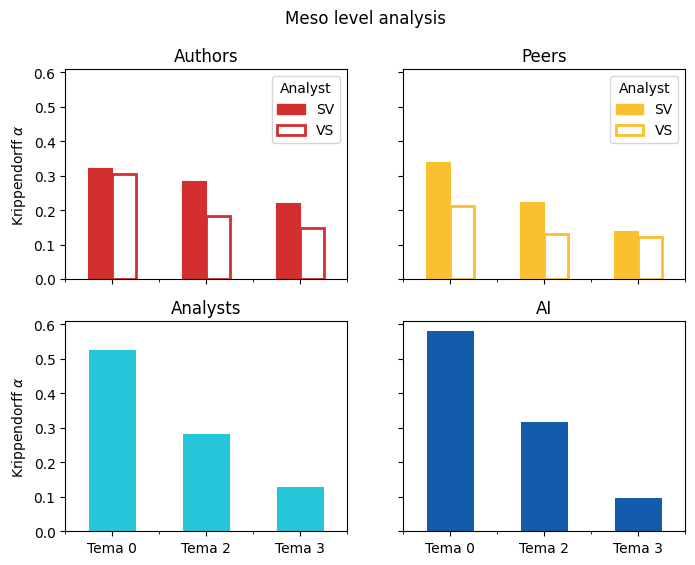

In [84]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(2,2, sharex=True, sharey=True, figsize=(8,6))

dfs_meso = {k : dfs_meso[k] for k in ['Authors', 'Peers', 'Analysts', 'AI']}

for idx, ((label, df), ax) in enumerate(zip(dfs_meso.items(), axes.flat)):
    if label in ['Authors', 'Peers']:
        legend = True
    else:
        legend = False
    
    df.plot(kind='bar', ax = ax, legend=legend, color=colors_single[idx])

    if label in ['Authors', 'Peers']:

        n_rows, n_cols = df.shape
        bars = ax.patches

        for col_idx in range(n_cols):
            for row_idx in range(n_rows):
                i = col_idx * n_rows + row_idx
                bar = bars[i]
        
                if col_idx == 0:
                    bar.set_facecolor(colors_single[idx])
                    bar.set_edgecolor(colors_single[idx])
                    bar.set_linewidth(1.5)
                else:
                    bar.set_facecolor("none")
                    bar.set_edgecolor(colors_single[idx])
                    bar.set_linewidth(2.0)
        legend_items = [Patch(facecolor=colors_single[idx], edgecolor=colors_single[idx], label=df.columns[0]),
                        Patch(facecolor="none", edgecolor=colors_single[idx], linewidth=2, label=df.columns[1])]
        
        ax.legend(handles=legend_items, title="Analyst")


    ax.set_ylabel(r'Krippendorff $\alpha$')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_title(label)

fig.suptitle('Meso level analysis')
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso.png')
plt.show()

In [85]:
df = pd.concat({k : v for k,v in dfs_meso.items()}, axis = 1)
df.to_excel(f'{RESULTS_TABLES_DIR}/meso.xlsx')

#### Agreement ratio

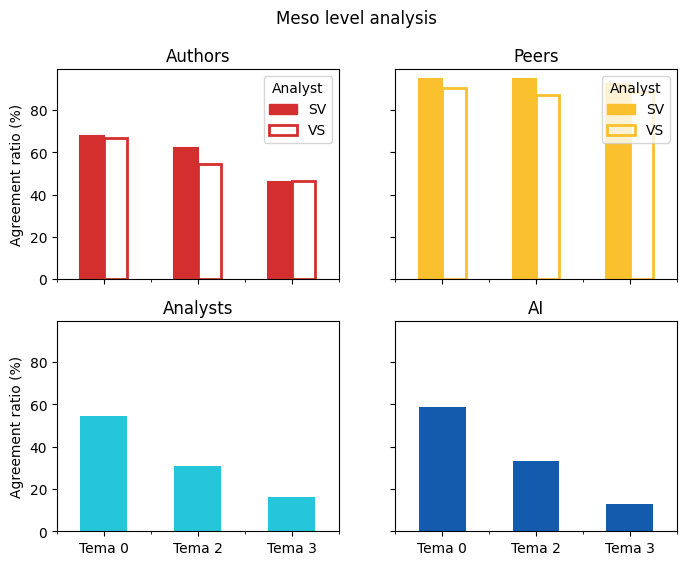

In [418]:
fig, axes = plt.subplots(2,2, sharex=True, sharey=True, figsize=(8,6))

dfs_meso_agreements = {k : dfs_meso_agreements[k] for k in ['Authors', 'Peers', 'Analysts', 'AI']}

for idx, ((label, df), ax) in enumerate(zip(dfs_meso_agreements.items(), axes.flat)):
    if label in ['Authors', 'Peers']:
        legend = True
    else:
        legend = False
    df.plot(kind='bar', ax = ax, legend=legend, color=colors_single[idx])

    if label in ['Authors', 'Peers']:

        n_rows, n_cols = df.shape
        bars = ax.patches

        for col_idx in range(n_cols):
            for row_idx in range(n_rows):
                i = col_idx * n_rows + row_idx
                bar = bars[i]
        
                if col_idx == 0:
                    bar.set_facecolor(colors_single[idx])
                    bar.set_edgecolor(colors_single[idx])
                    bar.set_linewidth(1.5)
                else:
                    bar.set_facecolor("none")
                    bar.set_edgecolor(colors_single[idx])
                    bar.set_linewidth(2.0)
        legend_items = [Patch(facecolor=colors_single[idx], edgecolor=colors_single[idx], label=df.columns[0]),
                        Patch(facecolor="none", edgecolor=colors_single[idx], linewidth=2, label=df.columns[1])]
        
        ax.legend(handles=legend_items, title="Analyst")
    
    ax.set_ylabel('Agreement ratio (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_title(label)

fig.suptitle('Meso level analysis')
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_agreemet.png')
plt.show()

In [419]:
df = pd.concat({k : v for k,v in dfs_meso_agreements.items()}, axis = 1)
df.to_excel(f'{RESULTS_TABLES_DIR}/meso_agreement.xlsx')

#### Human vs AI correspondence

In [97]:
flat = {}

for dimension, df in dfs.items():
    df_flat = df.copy()
    df_flat.columns = ["_".join(map(str, col)) for col in df.columns]

    flat[dimension] = df_flat

dfs_flat = pd.concat({k : v for k,v in flat.items()}, axis=1)

def get_human_ai_correspondence(row):

    human = row[row.index.get_level_values(0).isin(['Authors','Peers', 'Analysts'])].dropna()
    ai = row[row.index.get_level_values(0).isin(['AI'])].dropna()

    human_categories = set(human.unique())
    ai_categories = set(ai.unique())
    
    if len(human_categories.intersection(ai_categories)):
        return True
    else:
        return False

dfs_flat['correspondence'] = dfs_flat.apply(get_human_ai_correspondence, axis = 1)

dfs_flat['correspondence'].describe()


count      178
unique       2
top       True
freq       150
Name: correspondence, dtype: object

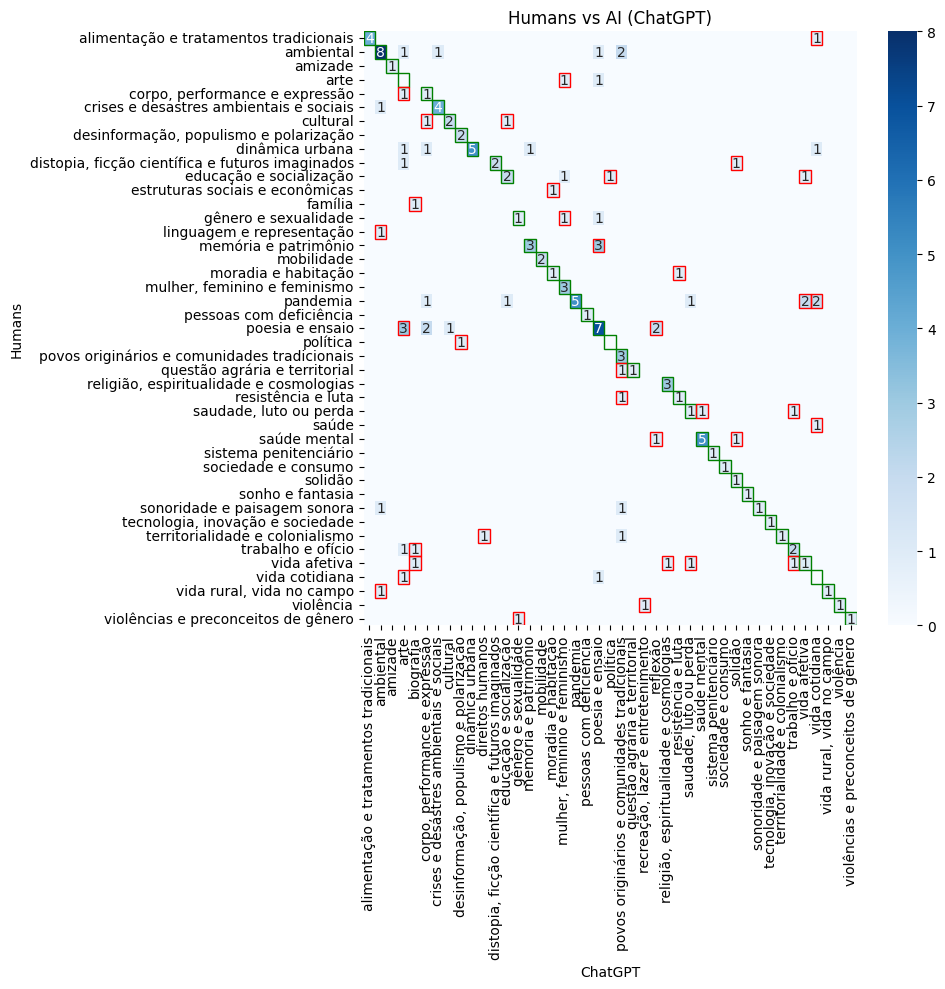

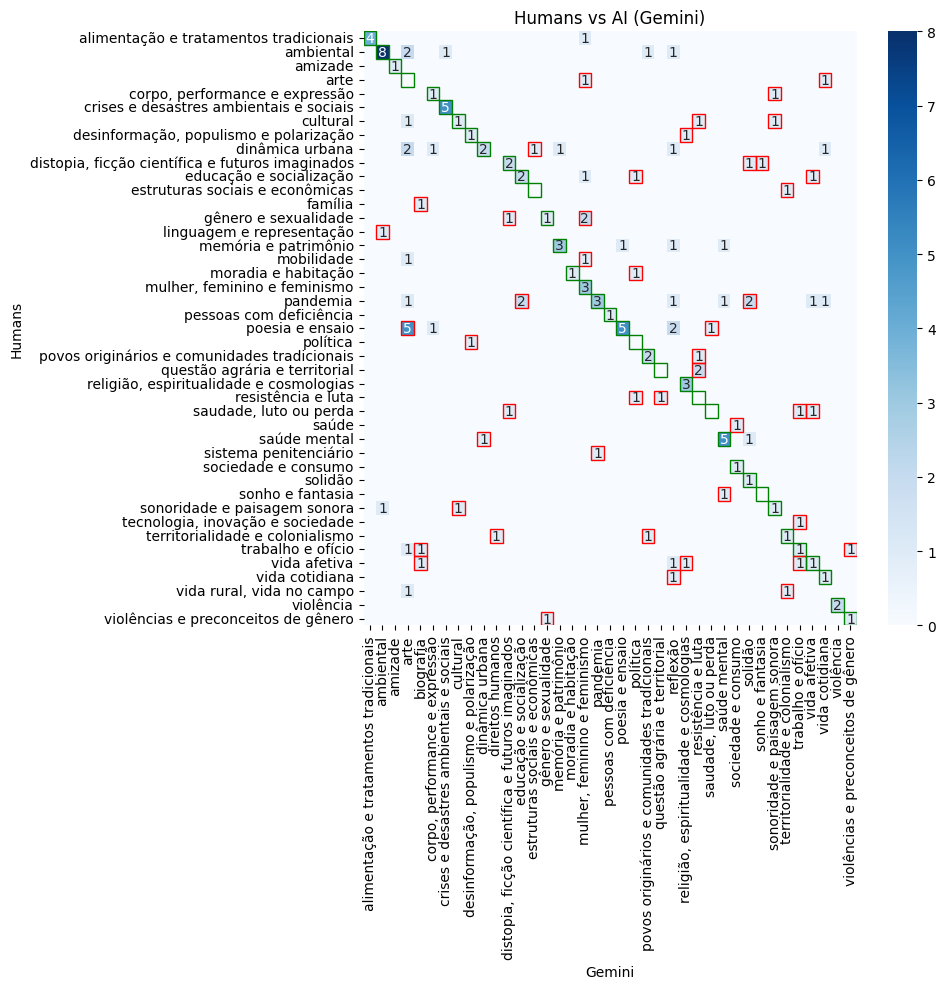

In [144]:
import matplotlib.patches as patches

_dfs_flat = dfs_flat.drop('correspondence', axis=1)

mask_human = _dfs_flat.columns.get_level_values(0).isin(['Analysts', 'Authors', 'Peers'])
mask_theme_0 = _dfs_flat.columns.get_level_values(-1).str.contains('Tema 0')
mask_theme_0

df_humans = _dfs_flat.loc[:, mask_human & mask_theme_0]

mode_humans = df_humans.mode(axis=1, dropna=True)[0]
#mode_humans = df_authors_meso_wide.xs('Tema 0', level='level', axis=1).mode(axis=1, dropna=True)[0] #xs(5, level='score', axis = 1)
mode_humans.name = 'Humans'

ais = ['ChatGPT','Gemini']

for ai in ais: 

    df_ai = df_merge_ai.xs(ai, level='rater', axis = 1)['Tema 0']
    df_ai.name = ai
    
    ct = pd.crosstab(mode_humans, df_ai)

    chi2, p, dof, expected = chi2_contingency(ct)
    expected = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
    resid = (ct - expected) / np.sqrt(expected)

    mask_zeros = ct == 0
    annot_data = ct.astype(str)
    annot_data[mask_zeros] = ""

    fig, ax = plt.subplots(1,1, figsize=(10,10))
    sns.heatmap(ct, annot=annot_data, cmap="Blues", fmt="", ax = ax)

    for i, row_label in enumerate(ct.index):
        for j, col_label in enumerate(ct.columns):
            # Case 1: SAME category (diagonal by label) → green square
            if row_label == col_label:
                ax.add_patch(
                    patches.Rectangle(
                        (j, i), 1, 1,
                        fill=False,
                        edgecolor="green",
                        linewidth=1
                    )
                )
                continue

            # Case 2: OFF-diagonal residuals → red (overuse) / blue (underuse)
            r = resid.iat[i, j]
            e = expected.iat[i, j]
            if not np.isfinite(r) or e <= 0:
                continue

            # Optional significance threshold
            if abs(r) < 2:
                continue

            edge = "red" if r > 0 else "blue"
            ax.add_patch(
                patches.Rectangle(
                    (j, i), 1, 1,
                    fill=False,
                    edgecolor=edge,
                    linewidth=1
                )
            )

    plt.xlabel(ai)
    plt.ylabel('Humans')
    plt.title(f"Humans vs AI ({ai})")
    plt.tight_layout()

    fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_humans_vs_{ai}.png', dpi = 300)
    ct.to_excel(f'{RESULTS_TABLES_DIR}/meso_humans_vs_{ai}.xlsx')

    plt.show()

#### MASI

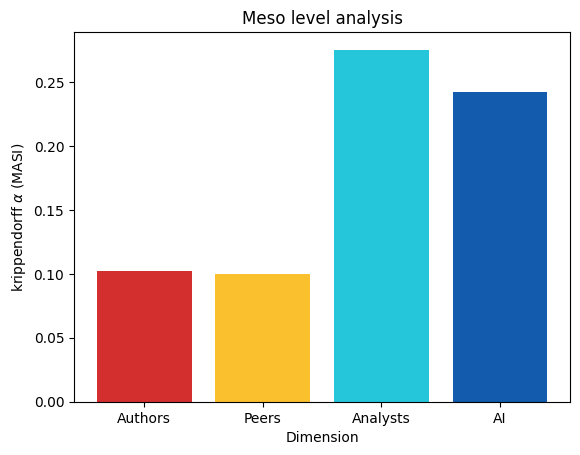

In [100]:
alphas = []
for dimension, df in dfs.items():
    alpha = engineering.krippendorff_alpha_masi(df)
    alphas.append(alpha)    

plt.bar(dfs.keys(), alphas, color = colors_single)
plt.xlabel('Dimension')
plt.ylabel(r'krippendorff $\alpha$ (MASI)')
plt.title('Meso level analysis')
plt.savefig(f'{RESULTS_FIGURES_DIR}/meso_MASI.png', dpi = 300)
plt.show()

df = pd.DataFrame([alphas], columns=dfs.keys())
df.to_excel(f'{RESULTS_TABLES_DIR}/meso_MASI.xlsx')

### Category agreement

In [101]:
categories = set()
for df in dfs.values():
    for col in df.columns:
        categories.update(df[col].dropna().unique())
categories = sorted(list(categories), reverse=True)

In [ ]:
results = []
for dimension, df in dfs.items():

    df_labels = df.xs('Tema 0', level=-1, axis = 1)
    if dimension in ['Authors', 'Peers']:
        df_labels = (df_labels.stack(level=0, future_stack=True).reset_index()).set_index('film_id').drop('supervisor', axis = 1)
    alphas = []
    for cat in categories:
        df_cat = (df_labels == cat).astype(float)
        if df_cat.sum().sum() == 0:
            alpha = np.nan
        else:
            alpha = krippendorff.alpha(reliability_data=df_cat.T, level_of_measurement='nominal')
        alphas.append(alpha)
    
    results.append(alphas)

df_alphas_categories = pd.DataFrame(np.asarray(results).T, columns=dfs.keys(), index = categories)    

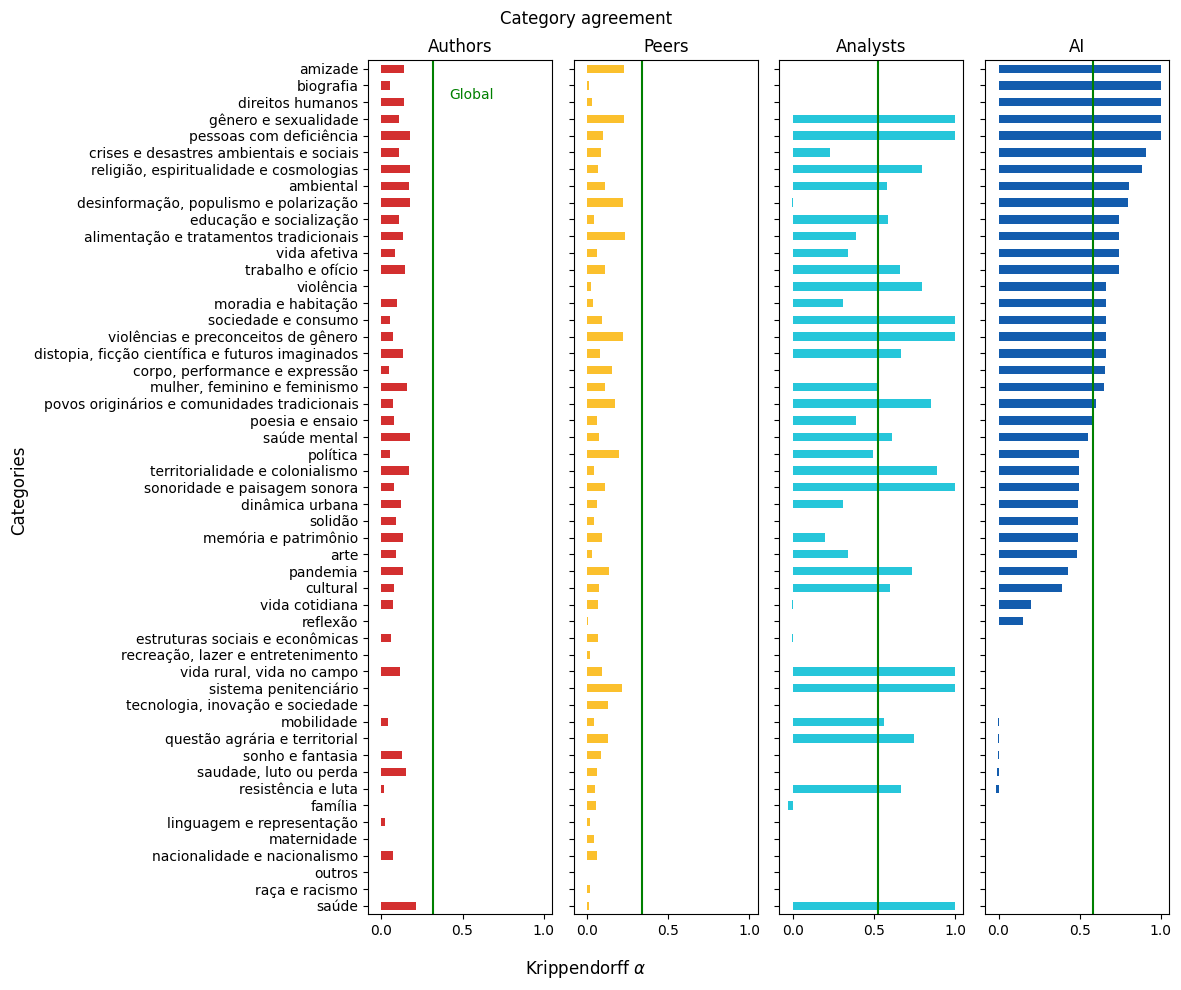

In [103]:
fig, axes = plt.subplots(1,4, sharex=True, sharey=True, figsize=(12,10))

df_sorted = df_alphas_categories['AI'].sort_values(na_position='first')
df_alphas_categories_sorted = df_alphas_categories.loc[df_sorted.index]

for idx, (col, ax) in enumerate(zip(['Authors', 'Peers', 'Analysts', 'AI'], axes.flat)):
    
    df_alphas_categories_sorted[col].plot(kind='barh', ax = ax, color = colors_single[idx])
    ax.set_title(col)
    ax.axvline(dfs_meso[col].loc['Tema 0'].values[0], color = 'green')
    ax.set_xticks([0,0.5,1])

    if ax == axes[0]:
        ax.text(x=dfs_meso[col].loc['Tema 0'].values[0] + 0.1, y = 48,
        s='Global', 
        color='green', 
        fontsize=10,
        va='bottom',
        ha='left',
        backgroundcolor='white'
        )

fig.suptitle('Category agreement')
fig.supxlabel(r'Krippendorff $\alpha$')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_per_cat.png', dpi = 300)
plt.show()

df_alphas_categories_sorted.to_excel(f'{RESULTS_TABLES_DIR}/meso_per_cat.xlsx')

In [105]:
results = []
for dimension, df in dfs.items():

    agreements = []
    for cat in categories:
        df_cat = (df == cat).astype(float)
        
        agreement_ratio = ((df_cat.eq(1).sum(axis=1) > 1).sum() / len(df_cat))*100
        agreements.append(agreement_ratio)
    
    results.append(agreements)

df_agreements_categories = pd.DataFrame(np.asarray(results).T, columns=dfs.keys(), index = categories)    

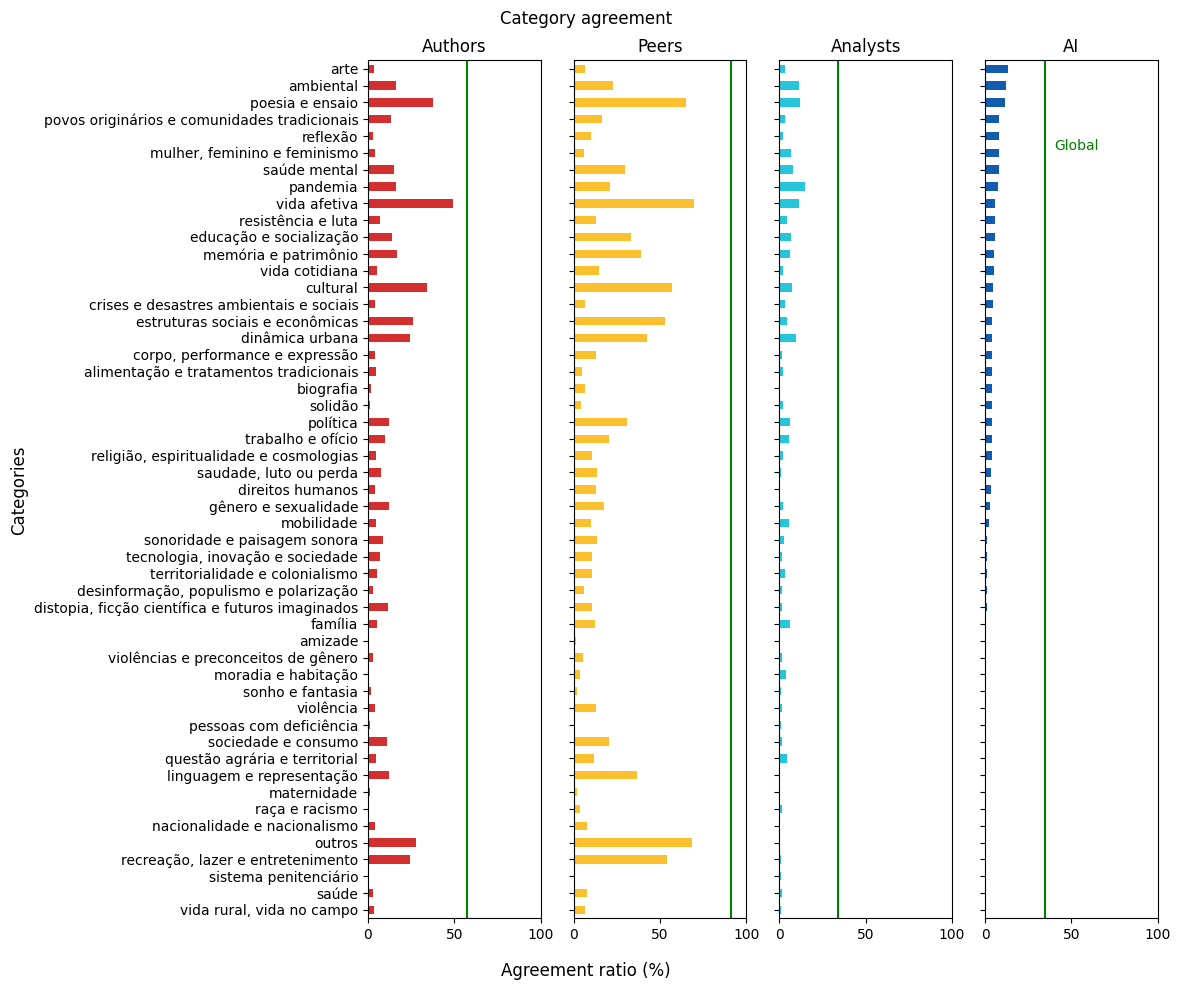

In [106]:
df_agreements_categories = df_agreements_categories.sort_values(by='AI', na_position='first')

fig, axes = plt.subplots(1,4, sharex=True, sharey=True, figsize=(12,10))

for idx, (col, ax) in enumerate(zip(df_agreements_categories.columns, axes.flat)):
    df_agreements_categories[col].plot(kind='barh', ax = ax, color = colors_single[idx])
    ax.set_title(col)
    if col in ['Authors', 'Peers']:
        vline = dfs_meso_agreements[col].mean().mean()
    else:
        vline = dfs_meso_agreements[col].mean().values[0] 
    ax.axvline(vline, color = 'green')
    ax.set_xticks([0,50,100])

    if ax == axes[-1]:
        ax.text(x=vline + 5, y = 45,
        s='Global', 
        color='green', 
        fontsize=10,
        va='bottom',
        ha='left',
        backgroundcolor='white'
        )

fig.suptitle('Category agreement')
fig.supxlabel('Agreement ratio (%)')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_agreements_per_cat.png', dpi = 300)
plt.show()

df_agreements_categories.to_excel(f'{RESULTS_TABLES_DIR}/meso_agreements_per_cat.xlsx')

### Category usage

#### By dimension

In [107]:
long_frames = []

for dimension, df in dfs.items():
    tmp = df.copy()
    tmp = tmp.reset_index()
    tmp = tmp.rename(columns={tmp.columns[0]: "film_id"})
    
    flat_cols = []
    for col in tmp.columns:
        if any(str(c) == "film_id" for c in col):
            flat_cols.append("film_id")
        else:
            parts = [str(c) for c in col if c not in (None, "", "nan")]
            flat_cols.append("_".join(parts))
    tmp.columns = flat_cols

    label_cols = [c for c in tmp.columns if c != 'film_id']

    tmp_long = tmp.melt(
        id_vars="film_id",
        value_vars=label_cols,
        var_name="rater_level",
        value_name="label")

    tmp_long["group"] = dimension
    tmp_long = tmp_long.dropna(subset=["label"])

    long_frames.append(tmp_long)

df_long = pd.concat(long_frames, ignore_index=True)

category_counts = (
    df_long
    .groupby(["group", "label"])
    .size()
    .unstack(fill_value=0)
)

category_counts = category_counts.loc[['Authors', 'Peers', 'Analysts', 'AI']]

In [122]:
category_counts.T.to_excel(f'{RESULTS_TABLES_DIR}/meso_category_counts.xlsx')

* Absolute frequency

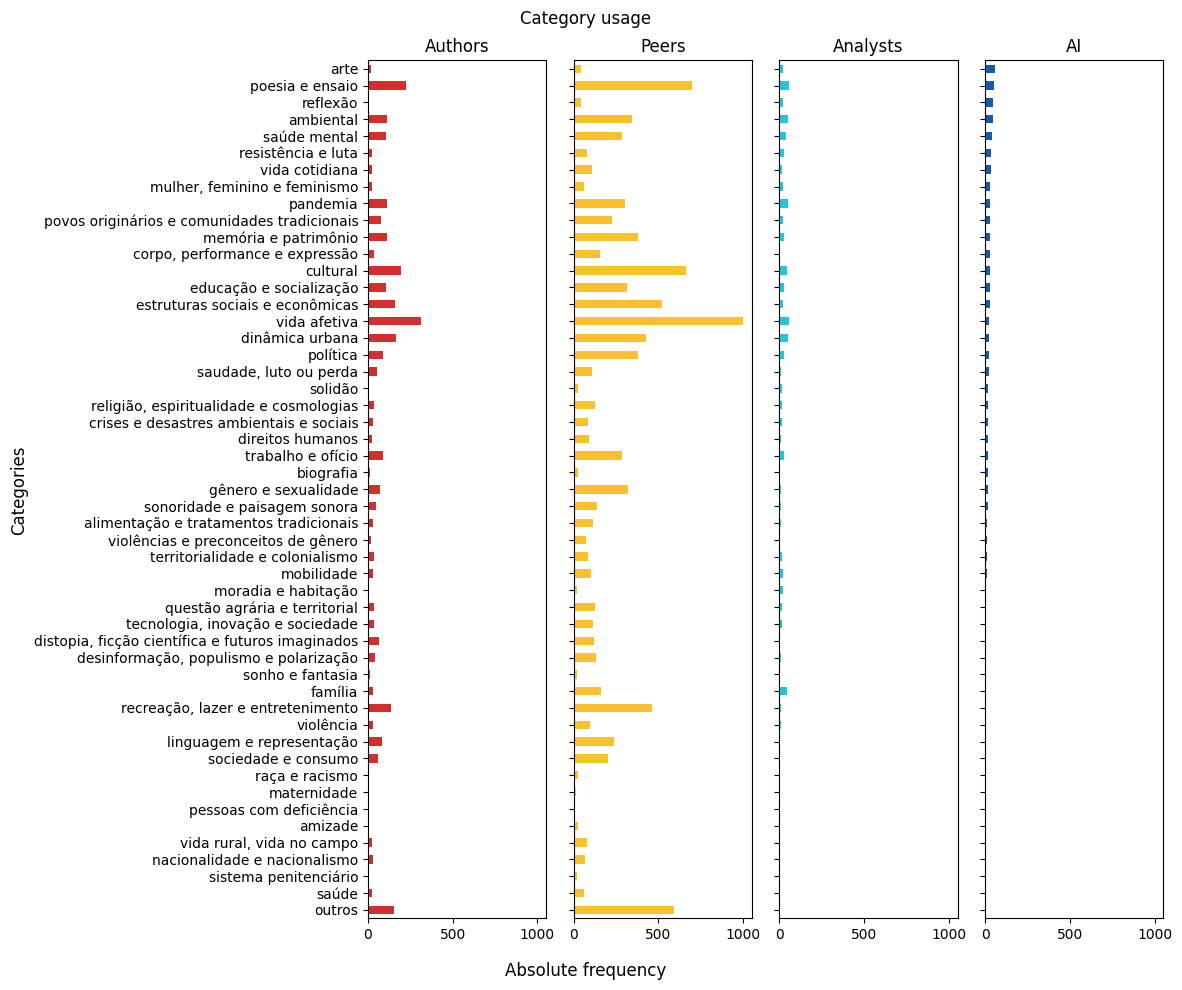

In [123]:
fig, axes = plt.subplots(1,4, sharey=True, sharex=True, figsize=(12,10))

category_counts_sorted = category_counts.T.sort_values(by='AI', na_position='first')

for idx, (dimension, ax) in enumerate(zip(category_counts_sorted.columns, axes.flat)):
    category_counts_sorted[dimension].plot(kind='barh', ax = ax, color=colors_single[idx])
    ax.set_ylabel('')
    ax.set_title(dimension)
    
fig.suptitle('Category usage')
fig.supxlabel('Absolute frequency')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_category_usage_frequency.png', dpi = 300)
plt.show()

category_counts_sorted.to_excel(f'{RESULTS_TABLES_DIR}/meso_category_usage_frequency.xlsx')

* Relative frequency

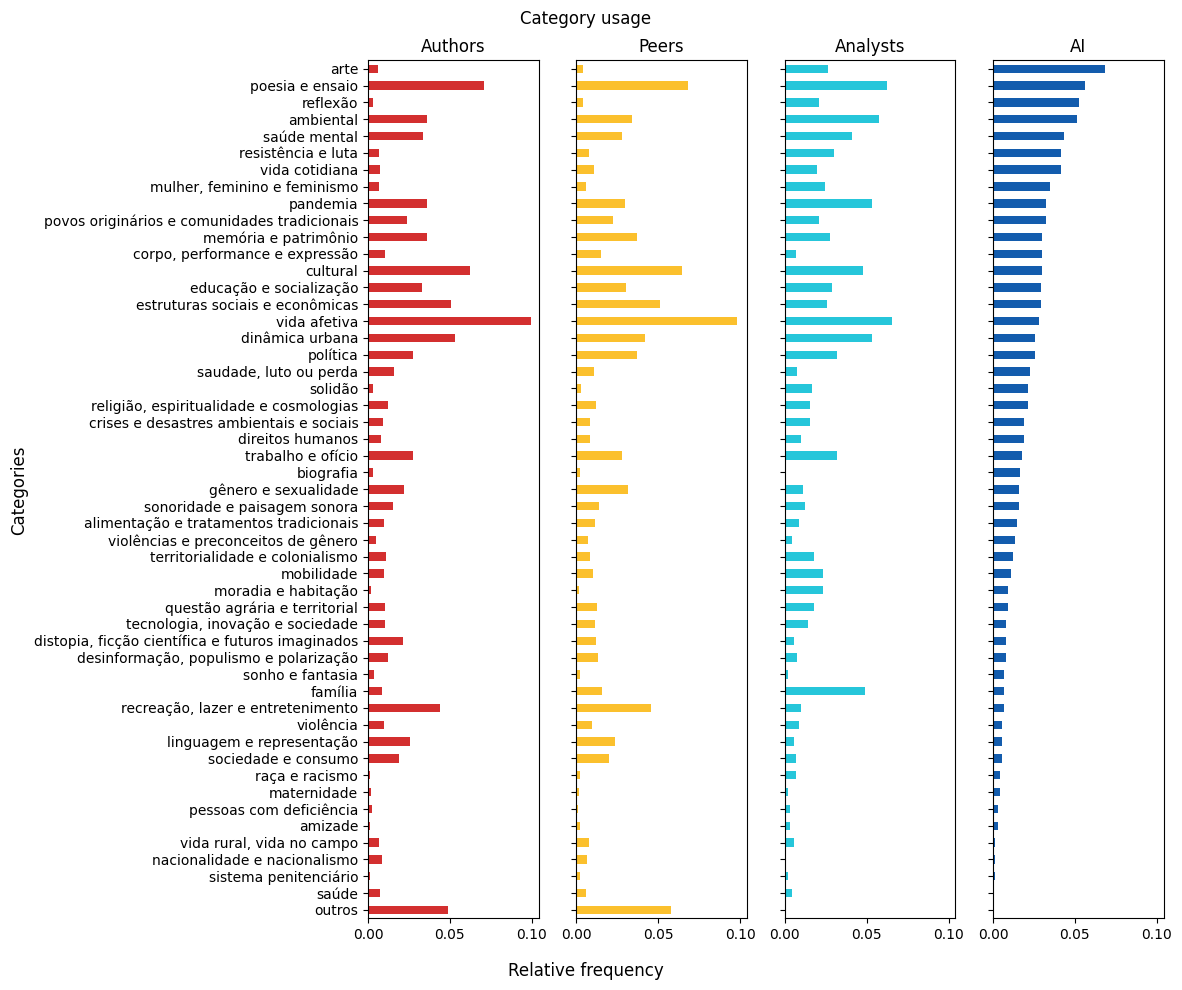

In [124]:
category_counts_normalized = category_counts.div(category_counts.sum(axis=1), axis = 0)

fig, axes = plt.subplots(1,4, sharey=True, sharex=True, figsize=(12,10))

category_counts_normalized_sorted = category_counts_normalized.T.sort_values(by='AI', na_position='first')

for idx, (dimension, ax) in enumerate(zip(category_counts_normalized_sorted.columns, axes.flat)):
    category_counts_normalized_sorted[dimension].plot(kind='barh', ax = ax, color=colors_single[idx])
    ax.set_ylabel('')
    ax.set_title(dimension)
    
fig.suptitle('Category usage')
fig.supxlabel('Relative frequency')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_category_usage_frequency_relative.png', dpi = 300)
plt.show()

category_counts_normalized_sorted.to_excel(f'{RESULTS_TABLES_DIR}/meso_category_usage_frequency_relative.xlsx')

* Quantitative bias obtained with chi-square calculation.

In [ ]:
chi2, p, dof, expected = chi2_contingency(category_counts)

expected = pd.DataFrame(
    expected,
    index=category_counts.index,
    columns=category_counts.columns,
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)

residuals = (category_counts - expected) / np.sqrt(expected)

Chi-square statistic: 1895.7551179499164
Degrees of freedom: 150
p-value: 1.3720871631436334e-299


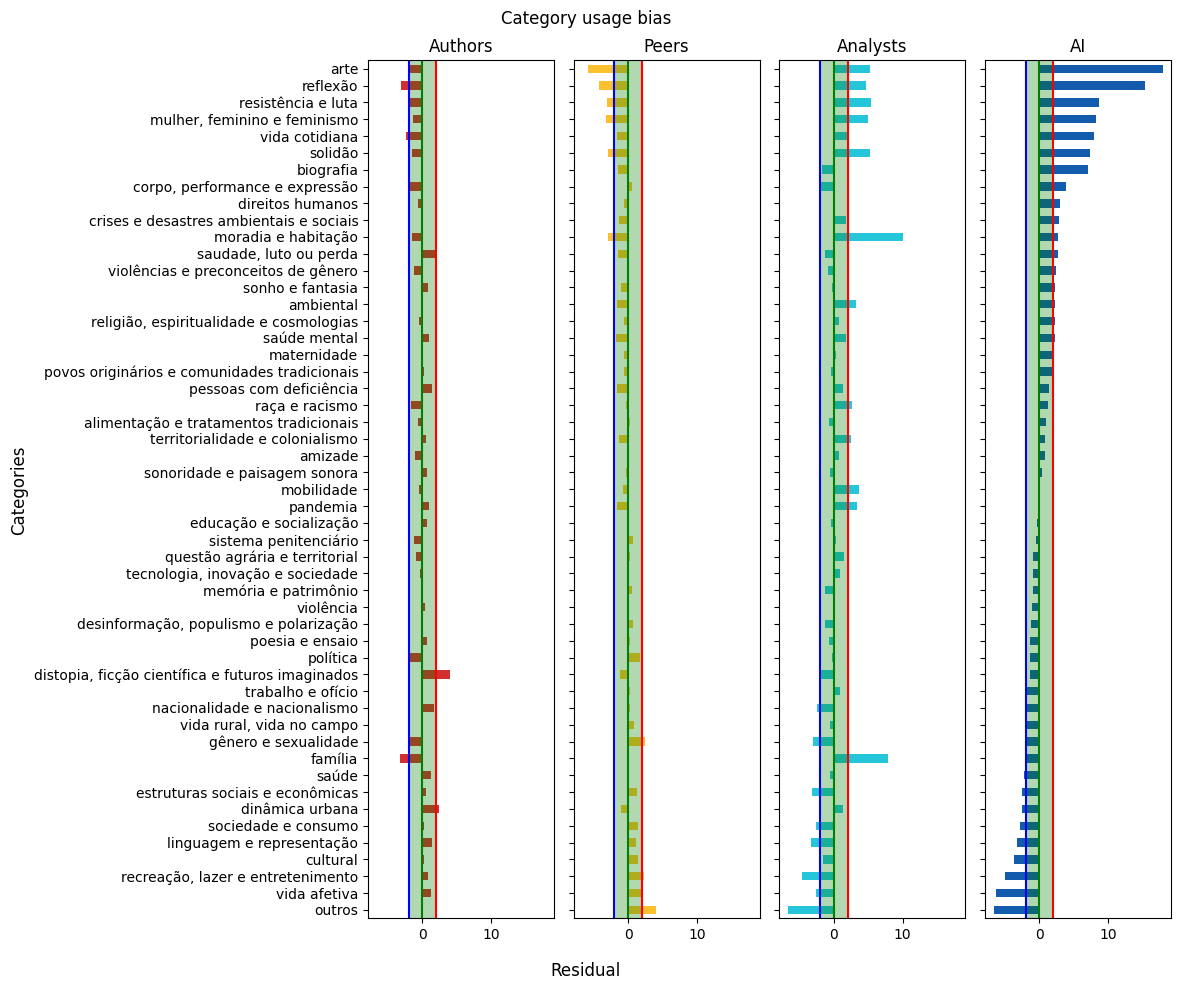

In [113]:
residuals_sorted = residuals.T.sort_values(by='AI', na_position='first')

fig, axes = plt.subplots(1,4, sharex=True, sharey=True, figsize=(12,10))

for idx, (dimension, ax) in enumerate(zip(residuals_sorted.columns, axes.flat)):

    residuals_sorted[dimension].plot(kind='barh', ax = ax, color = colors_single[idx])

    ax.axvline(0, color = 'green')
    ax.axvspan(-2,2, alpha = 0.3, color='green', linewidth=0)
    ax.axvline(-2, color = 'blue', linewidth=1.5) #residuals_sorted.min().min()
    ax.axvline(2, color = 'red', linewidth=1.5) # residuals_sorted.max().max()

    ax.set_ylabel('')
    ax.set_title(dimension)

fig.suptitle('Category usage bias')
fig.supxlabel('Residual')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_category_bias.png', dpi = 300)
plt.show()

residuals_sorted.to_excel(f'{RESULTS_TABLES_DIR}/meso_category_bias.xlsx')

#### By agent

In [114]:
_df_authors = df_authors.reset_index().copy()

_df_authors['rater_index'] = (_df_authors.groupby(['film_id', 'Analista', column_author_level]).cumcount() + 1)

df_authors_meso_wide = (_df_authors
                        .set_index(['film_id', 'Analista', column_author_level, 'rater_index'])[column_themes]
                        .unstack(['Analista', column_author_level,'rater_index']))

df_authors_meso_wide.columns = df_authors_meso_wide.columns.reorder_levels([1, 2, 3, 0])
df_authors_meso_wide.columns = df_authors_meso_wide.columns.set_names(['supervisor', 'score', 'rater', 'level'])
df_authors_meso_wide = df_authors_meso_wide.sort_index(axis=1, level = 0)

In [118]:
long_frames = []

dfs_meso_agents = dfs.copy()

dfs_meso_agents['Authors'] = df_authors_meso_wide

for dimension, df in dfs_meso_agents.items():
    tmp = df.copy()
    tmp = tmp.reset_index()
    tmp = tmp.rename(columns={tmp.columns[0]: "film_id"})
    
    flat_cols = []
    for col in tmp.columns:
        if any(str(c) == "film_id" for c in col):
            flat_cols.append("film_id")
        else:
            parts = [str(c) for c in col if c not in (None, "", "nan")]
            flat_cols.append("_".join(parts))
    tmp.columns = flat_cols

    label_cols = [c for c in tmp.columns if c != 'film_id']

    tmp_long = tmp.melt(
        id_vars="film_id",
        value_vars=label_cols,
        var_name="rater_level",
        value_name="level")
    

    if dimension in ['Analysts', 'AI']:
        agents = [f'{dimension} {col.split('_')[0]}' for col in tmp_long['rater_level']]
    elif dimension == 'Peers':
        agents = [dimension] * len(tmp_long)
    else:
        agents = [f'{dimension} {' Score '.join(col.split('_')[:2])}' for col in tmp_long['rater_level']]

    tmp_long["group"] = agents
    tmp_long = tmp_long.dropna(subset=["level"])

    long_frames.append(tmp_long)

df_long = pd.concat(long_frames, ignore_index=True)

category_counts_agents = (
    df_long
    .groupby(["group", "level"])
    .size()
    .unstack(fill_value=0)
)


In [120]:
idx = category_counts_agents.index.to_series()

mask_authors = idx.str.contains('Authors', case=False, na=False)

level_from_idx = idx.str.extract(r'(Score\s+[135])')[0]

df_authors_avg = category_counts_agents[mask_authors].copy()
df_authors_avg['level_tmp'] = level_from_idx[mask_authors]

authors_avg = (
    df_authors_avg
    .groupby('level_tmp')
    .mean(numeric_only=True)
)
authors_avg = authors_avg.astype(int)
authors_avg.index = [f'Authors {lvl}' for lvl in authors_avg.index]

df_others = category_counts_agents[~mask_authors].copy()
df_others = df_others.loc[['Peers', 'Analysts SV','Analysts VS', 'AI ChatGPT', 'AI Gemini']]

category_counts_agents = pd.concat([authors_avg, df_others], axis=0)

* Absolute frequency

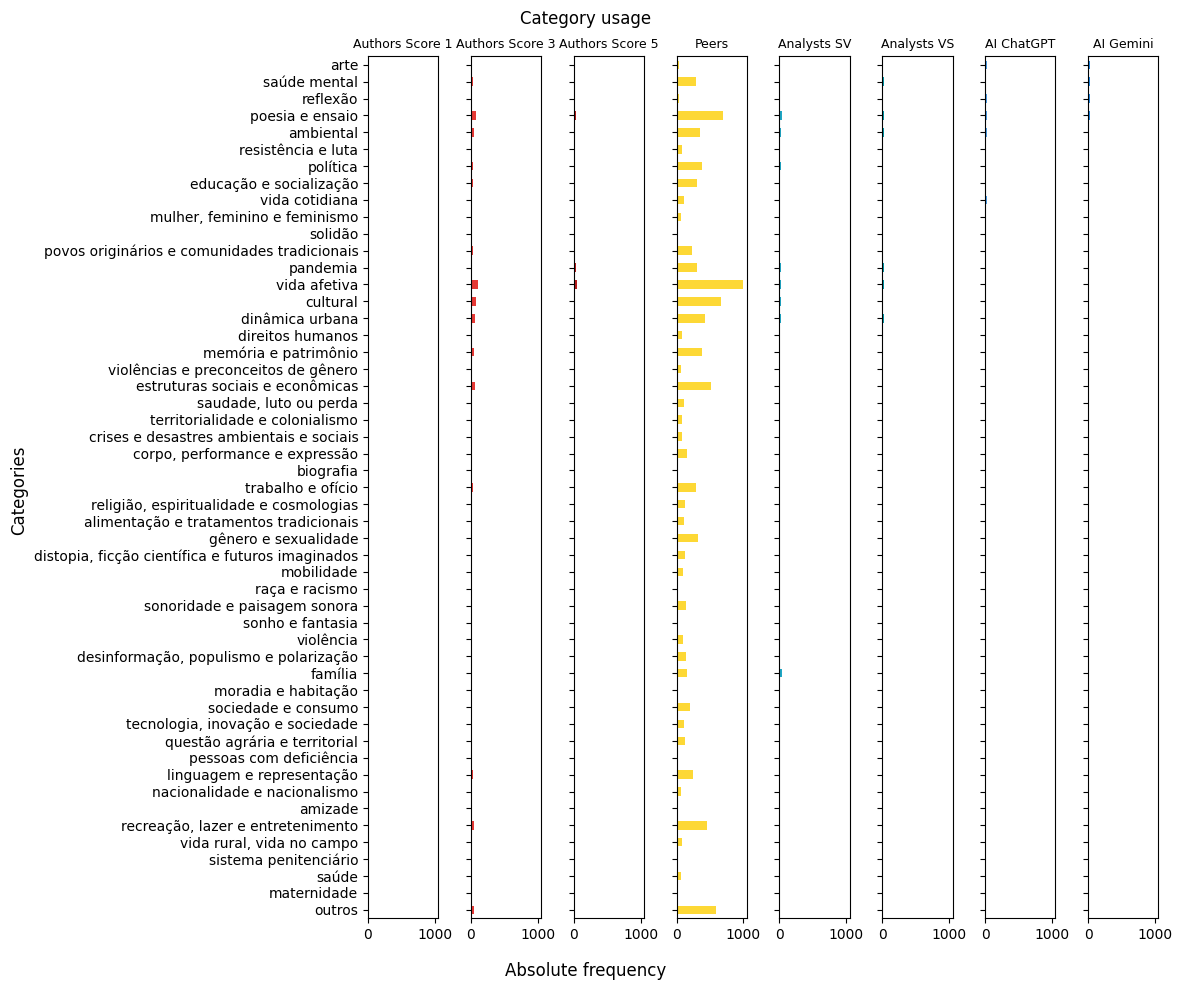

In [125]:
fig, axes = plt.subplots(1,len(category_counts_agents.T.columns), sharey=True, sharex=True, figsize=(12,10))

category_counts_agents_sorted = category_counts_agents.T.sort_values(by='AI Gemini', na_position='first')

for idx, (dimension, ax) in enumerate(zip(category_counts_agents_sorted.columns, axes.flat)):
    category_counts_agents_sorted[dimension].plot(kind='barh', ax = ax, color=colors_agents[idx])
    ax.set_ylabel('')
    ax.set_title(dimension, fontsize=9)
    
fig.suptitle('Category usage')
fig.supxlabel('Absolute frequency')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_category_usage_frequency_agents.png', dpi = 300)
plt.show()

category_counts_agents_sorted.to_excel(f'{RESULTS_TABLES_DIR}/meso_category_usage_frequency_agents.xlsx')

* Relative frequency

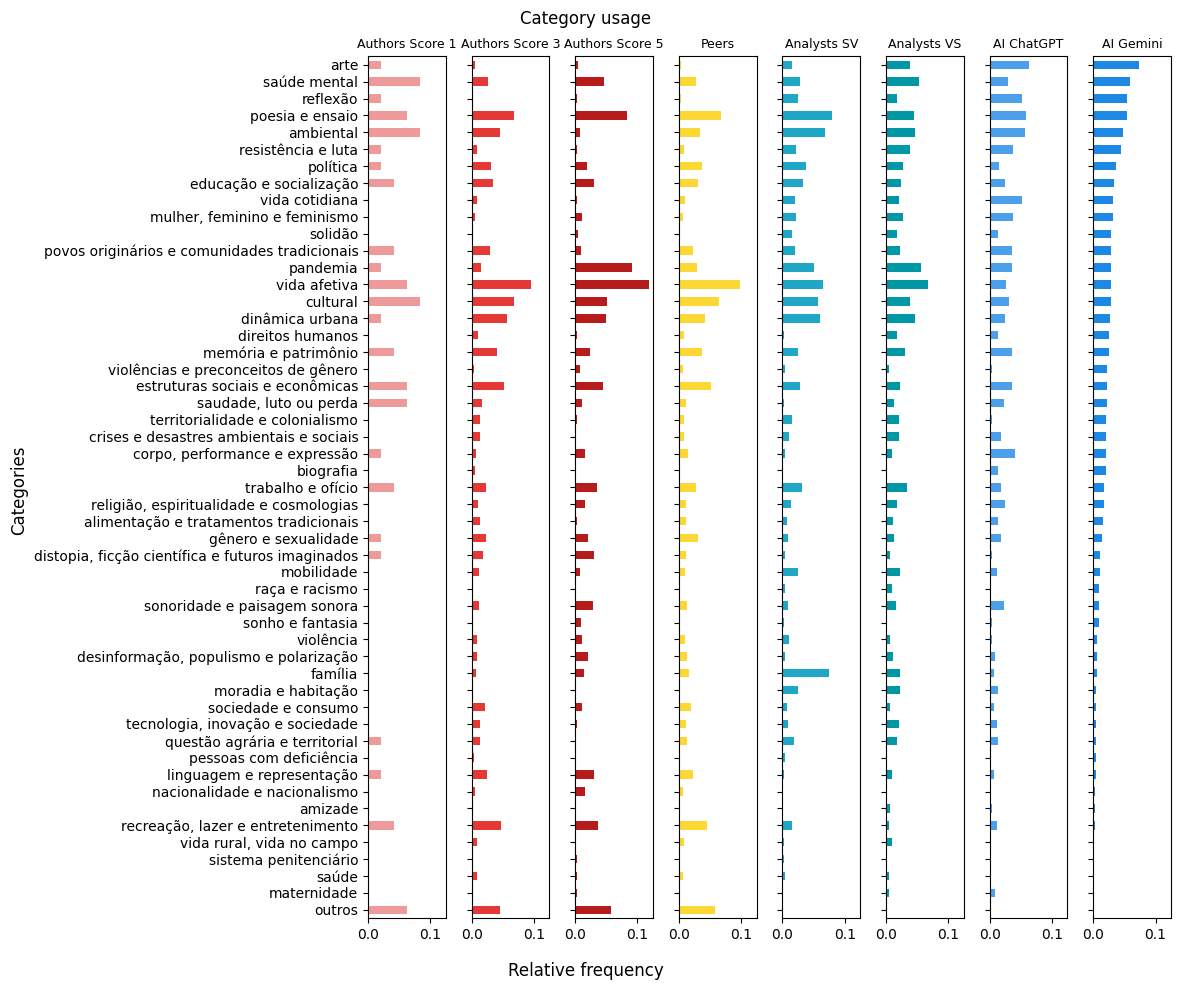

In [133]:
category_counts_agents_normalized = category_counts_agents.div(category_counts_agents.sum(axis=1), axis = 0)

fig, axes = plt.subplots(1,len(category_counts_agents.T.columns), sharey=True, sharex=True, figsize=(12,10))

category_counts_agents_normalized_sorted = category_counts_agents_normalized.T.sort_values(by='AI Gemini', na_position='first')

for idx, (dimension, ax) in enumerate(zip(category_counts_agents_normalized_sorted.columns, axes.flat)):
    category_counts_agents_normalized_sorted[dimension].plot(kind='barh', ax = ax, color=colors_agents[idx])
    ax.set_ylabel('')
    ax.set_title(dimension, fontsize=9)
    
fig.suptitle('Category usage')
fig.supxlabel('Relative frequency')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_category_usage_frequency_relative_agents.png', dpi = 300)
plt.show()

category_counts_agents_normalized_sorted.to_excel(f'{RESULTS_TABLES_DIR}/meso_category_usage_frequency_relative_agents.xlsx')

* Category usage bias by agent is obtained by calculation of chi-square values.

In [126]:
chi2, p, dof, expected = chi2_contingency(category_counts_agents)

expected = pd.DataFrame(
    expected,
    index=category_counts_agents.index,
    columns=category_counts_agents.columns,
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)

residuals_agents = (category_counts_agents - expected) / np.sqrt(expected)

Chi-square statistic: 2197.246589193088
Degrees of freedom: 350
p-value: 1.7723568102149443e-264


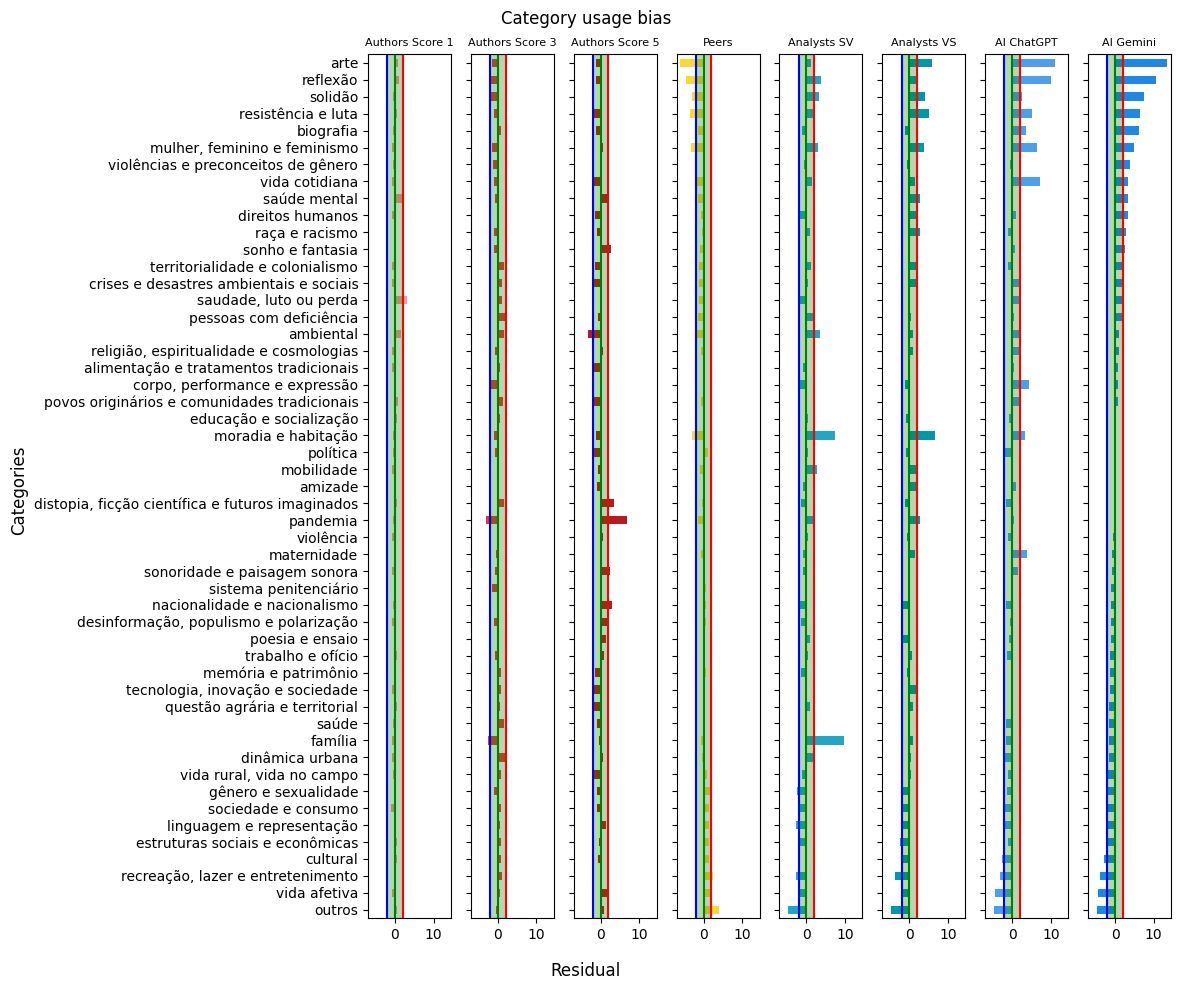

In [127]:
residuals_agents_sorted = residuals_agents.T.sort_values(by='AI Gemini', na_position='first')

fig, axes = plt.subplots(1,len(residuals_agents_sorted.columns), sharex=True, sharey=True, figsize=(12,10))

for idx, (dimension, ax) in enumerate(zip(residuals_agents_sorted.columns, axes.flat)):

    residuals_agents_sorted[dimension].plot(kind='barh', ax = ax, color = colors_agents[idx])

    ax.axvline(0, color = 'green')
    ax.axvspan(-2,2, alpha = 0.3, color='green')
    ax.axvline(-2, color = 'blue', linewidth=1.5) #residuals_agents_sorted.min().min()
    ax.axvline(2, color = 'red', linewidth=1.5) #residuals_agents_sorted.max().max()

    ax.set_ylabel('')
    ax.set_title(dimension, fontsize=8)

fig.suptitle('Category usage bias')
fig.supxlabel('Residual')
fig.supylabel('Categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_category_bias_agents.png', dpi = 300)
plt.show()

residuals_sorted.to_excel(f'{RESULTS_TABLES_DIR}/meso_category_bias_agents.xlsx')

### Film category entropy

In [128]:
df_all = pd.concat([df for df in dfs.values()], axis = 1)

df_entropy = engineering.per_film_entropy(df_all)
df_entropy.set_index('film_id', inplace =True)
df_entropy.to_excel(f'{RESULTS_TABLES_DIR}/meso_entropy.xlsx')

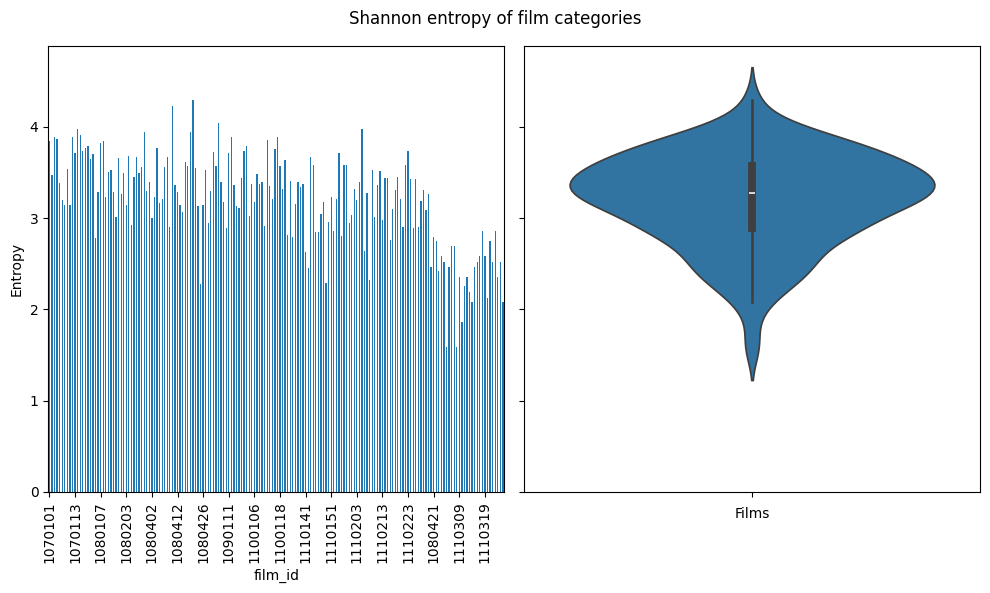

In [129]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(1,2, figsize = (10,6), sharey=True)

df_entropy['entropy'].plot(kind='bar', ax = ax[0])
sns.violinplot(data=df_entropy, y='entropy', ax = ax[1])
ax[0].xaxis.set_major_locator(MaxNLocator(nbins=20))
ax[0].set_ylabel('Entropy')
ax[1].set_xlabel('Films')
fig.suptitle('Shannon entropy of film categories')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/meso_per_film_entropy.png', dpi = 300)
plt.show()

#### Film entropy vs micro level 

C:\Users\User01\AppData\Local\Temp\ipykernel_28120\1886177039.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


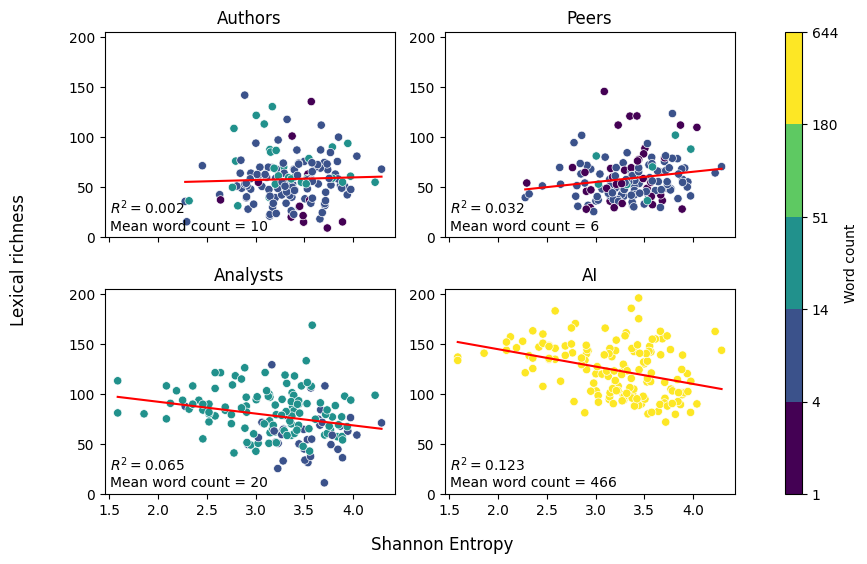

C:\Users\User01\AppData\Local\Temp\ipykernel_28120\1886177039.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


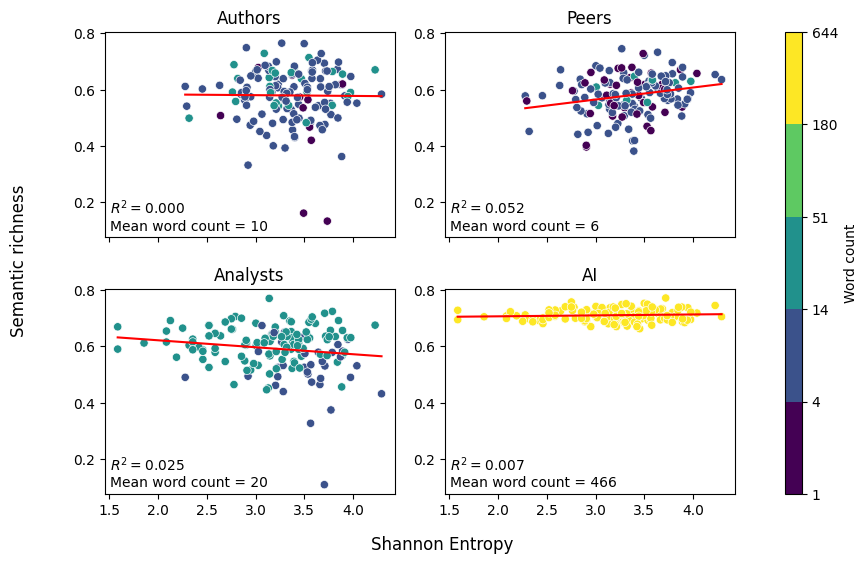

In [130]:
labels =[1,2,3,4,5]

for richness in ['lexical_richness', 'semantic_richness']:
    if richness == 'lexical_richness':
        label = 'Lexical richness'
    else:
        label = 'Semantic richness'

    fig = plt.figure(figsize=(9, 6))

    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.06], height_ratios = [1,1], hspace=0.25, wspace=0.25)

    ax1 = fig.add_subplot(gs[0,0])
    ax2 = fig.add_subplot(gs[0,1], sharex=ax1, sharey=ax1)
    ax3 = fig.add_subplot(gs[1,0], sharex=ax1, sharey=ax1)
    ax4 = fig.add_subplot(gs[1,1], sharex=ax1, sharey=ax1)

    ax1.tick_params(labelbottom=False)
    ax2.tick_params(labelbottom=False)

    axes = [ax1,ax2,ax3,ax4]

    df = df_micro_richness.xs(richness, level=0, axis = 1)

    for dimension, ax in zip(df.columns, axes):

        #df_merge = pd.merge(df_entropy['entropy'], df[dimension], on = 'film_id')
        
        df_merge = pd.concat([df_entropy['entropy'], df[dimension], df_bins[f'{dimension}_N']], axis = 1)

        df_merge.rename(columns={dimension : label}, inplace=True)
        mean_word_count = df_word_counts[f'{dimension}_N'].mean()
        
        sns.scatterplot(data=df_merge, 
                        x='entropy', 
                        y=label, 
                        hue=f'{dimension}_color',
                        hue_order=labels,
                        palette=palette, 
                        legend=False,
                        ax = ax)
        
        ax.set_title(dimension)
        ax.set_xlabel('')
        ax.set_ylabel('')

        x_range, y_pred, r2 = engineering.get_fitted(df_merge, 'entropy', label)

        ax.plot(x_range, y_pred, color='red')

        locs = 0.95 if richness == 'lexical_richess' else 0.02

        ax.text(
                0.02, locs,
                f"$R^2 = {r2:.3f}$\nMean word count = {mean_word_count:.0f}",
                transform=ax.transAxes,
                fontsize=10,
                va='bottom',
                ha='left'
            )
    
    cax = fig.add_subplot(gs[:, 2])

    sm = ScalarMappable(norm=norm_word, cmap=cmap_word)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cax)

    # Ticks at the bin edges, label nicely
    cbar.set_ticks(bins)
    cbar.set_ticklabels([f"{b:.0f}" for b in bins])
    cbar.set_label("Word count")

    fig.supylabel(label)
    fig.supxlabel('Shannon Entropy')
    fig.tight_layout()
    fig.savefig(f'{RESULTS_FIGURES_DIR}/{richness}_micro_vs_entropy.png', dpi = 300)
    plt.show()


## MCA

### By top categories

In [145]:
top_categories = pd.read_excel(f'{DATA_RAW_DIR}/Dados Integrados/v4-NOVO-TabelaSimples de Temas por Filmes e Agentes.xlsx', sheet_name=['An-Analistas Ambos', 'Au-Autores1a5', 'Pa-Pares', 'IA-IAs'])

<div style="
    background-color: #77b6e9ff;
    border-left:6px solid #77b6e9ff;
    padding:12px;
    border-radius:4px;
    font-family: sans-serif;
">
<strong>Note</strong><br>
Films that are below ID 1069000 are removed from analysis
</div>

In [146]:
df = top_categories['An-Analistas Ambos'][['ID Filme', 'Nome Filme']].copy()
df['film_id'] = df['ID Filme'].astype(str)
df['title'] = df['Nome Filme']
df_titles = df[['film_id','title']]
df_titles.loc[:,'film_id'] = df_titles['film_id'].astype(int)

df_titles = df_titles[df_titles['film_id'] > 1069000]
df_titles.set_index('film_id', inplace = True)

In [160]:
dimension_map = {'An-Analistas Ambos' : 'Analysts',
                 'Au-Autores1a5' : 'Authors',
                 'Pa-Pares' : 'Peers',
                 'IA-IAs' : 'AI'}

df_top_categories_list = []

for dimension, _df in top_categories.items():
    df = _df.copy()
    df['film_id'] = df['ID Filme']
    df = df[df['film_id'] > 1069000]
    df.set_index('film_id', inplace=True)
    df[dimension_map[dimension]] = df['Categoria-Tema'].str.replace(r'^\d+\.\s*', '', regex=True).str.lower()
    df_top_categories_list.append(df[dimension_map[dimension]])
    #dfs_categories[dimension_map[dimension]] = df[['category']]

df_top_categories = pd.concat(df_top_categories_list, axis = 1)

In [157]:
cats = pd.unique(df_top_categories.to_numpy().ravel())

cats = cats[~pd.isna(cats)]

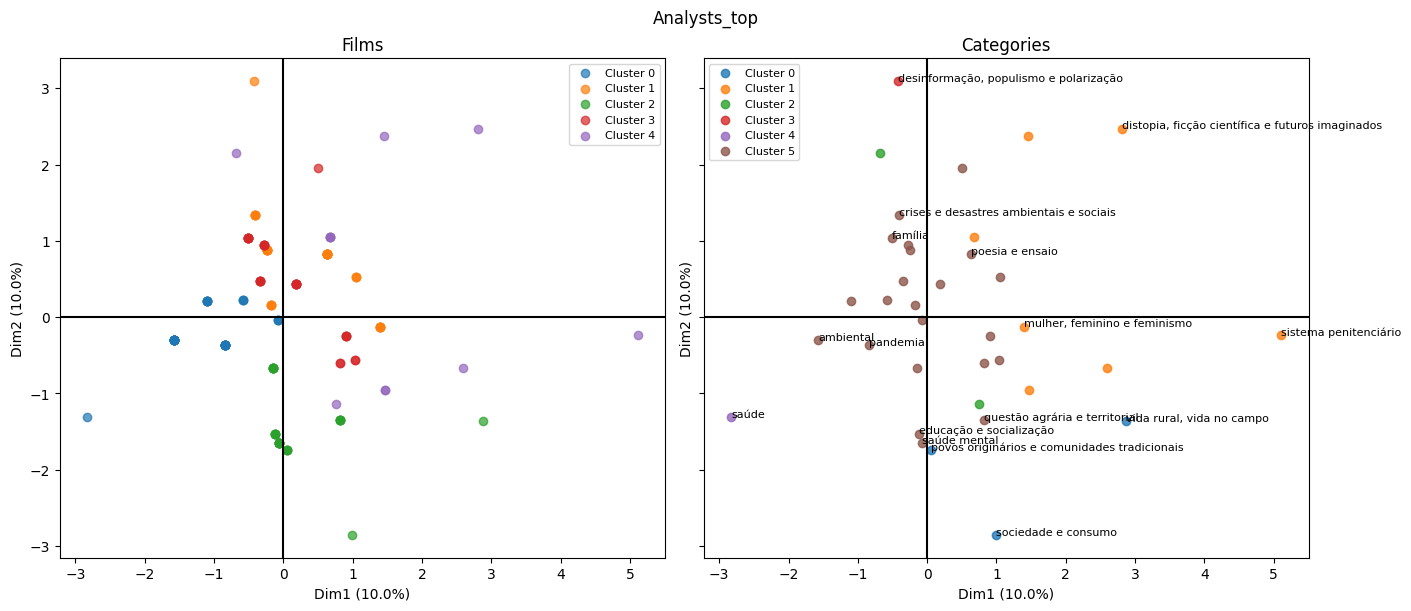

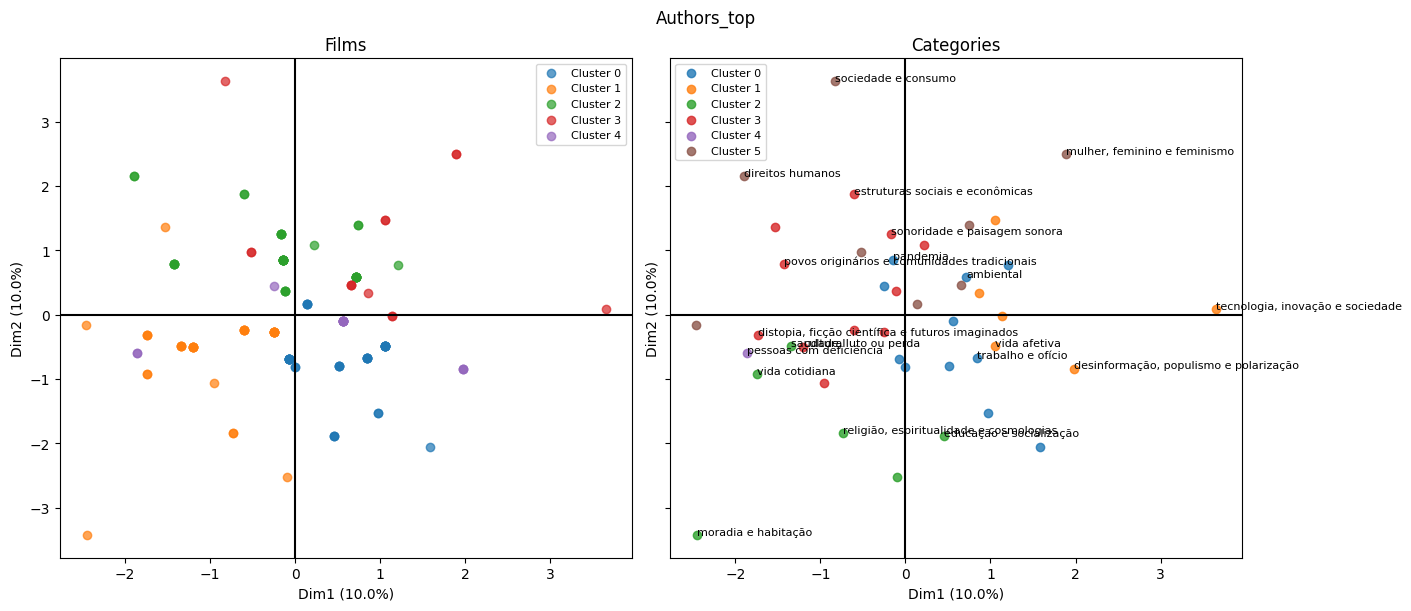

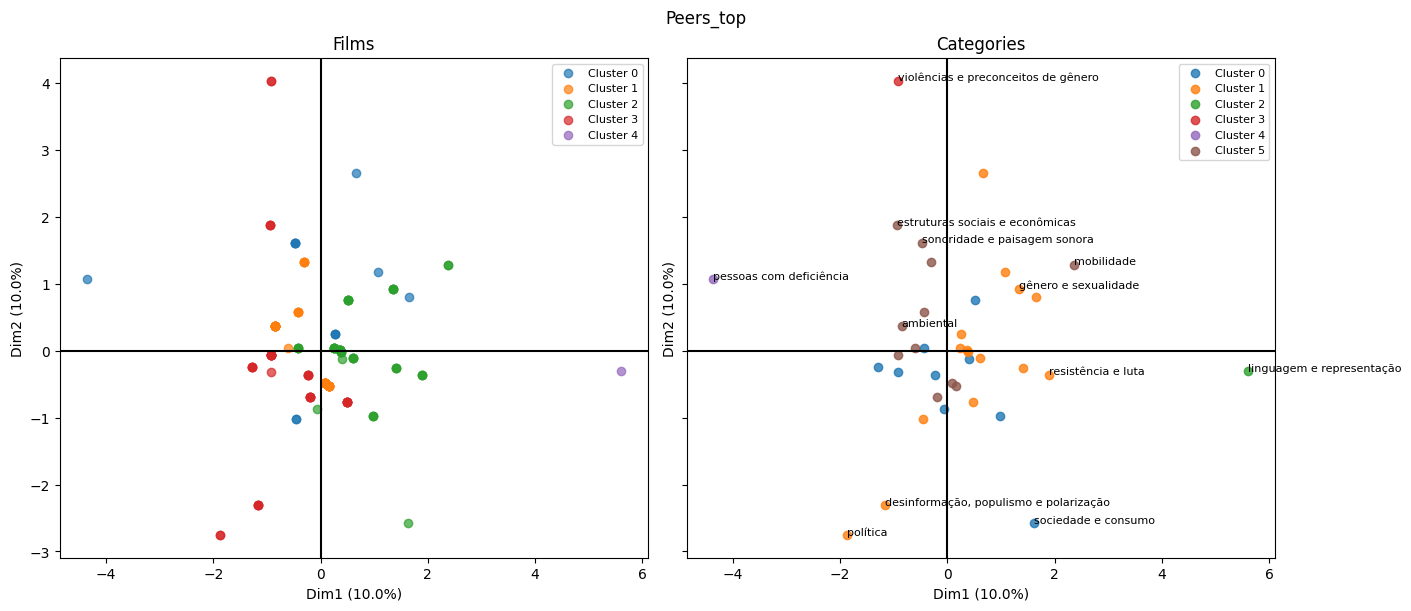

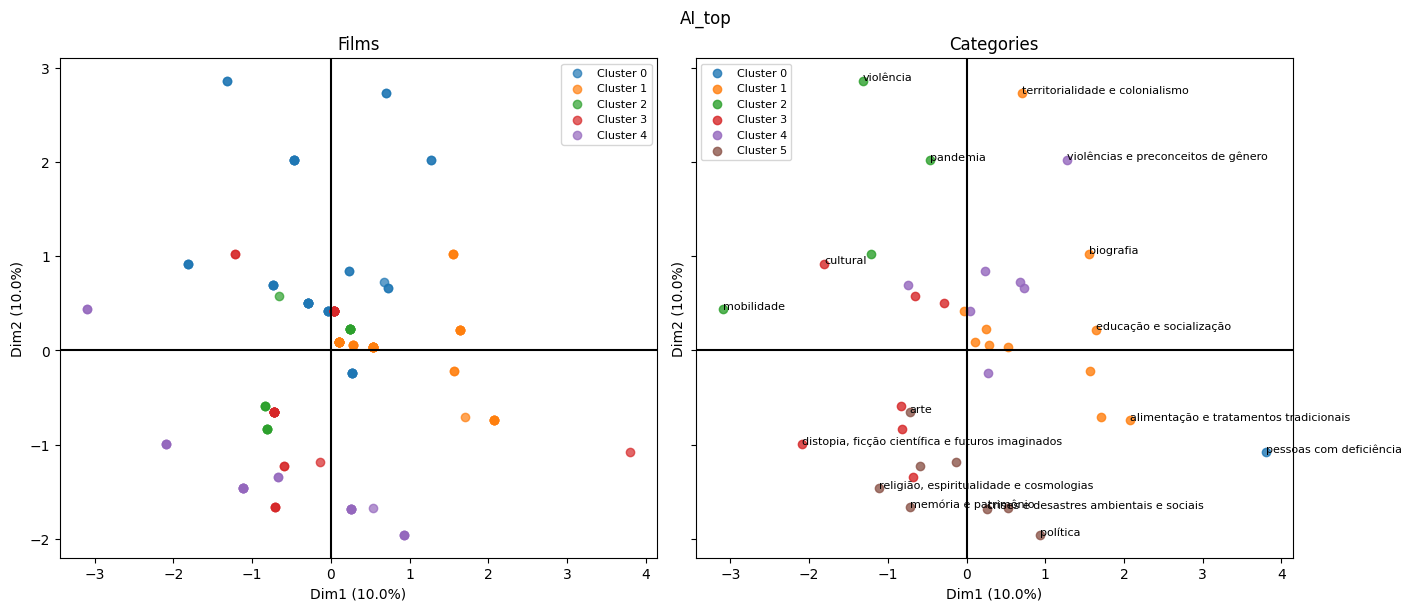

In [161]:
for col in df_top_categories.columns:

    X = engineering.get_binary_matrix(df_top_categories[col].to_frame(), cats)

    X = X[X.columns[X.sum(axis=0) > 0]]
    X = X.astype(float)

    engineering.get_mca(X, f'{col}_top', df_titles, RESULTS_FIGURES_DIR)

### By all categories

In [162]:
cats = pd.unique(
    np.concatenate([df.to_numpy().ravel() for df in dfs.values()])
)

cats = cats[~pd.isna(cats)]

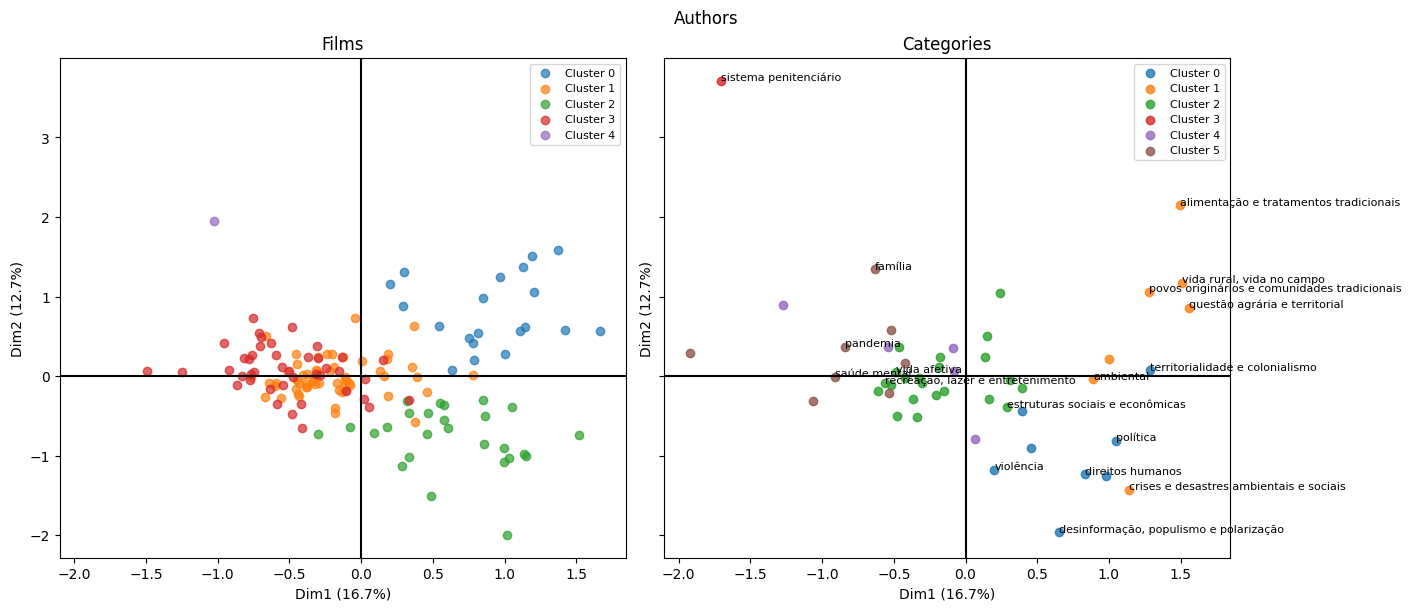

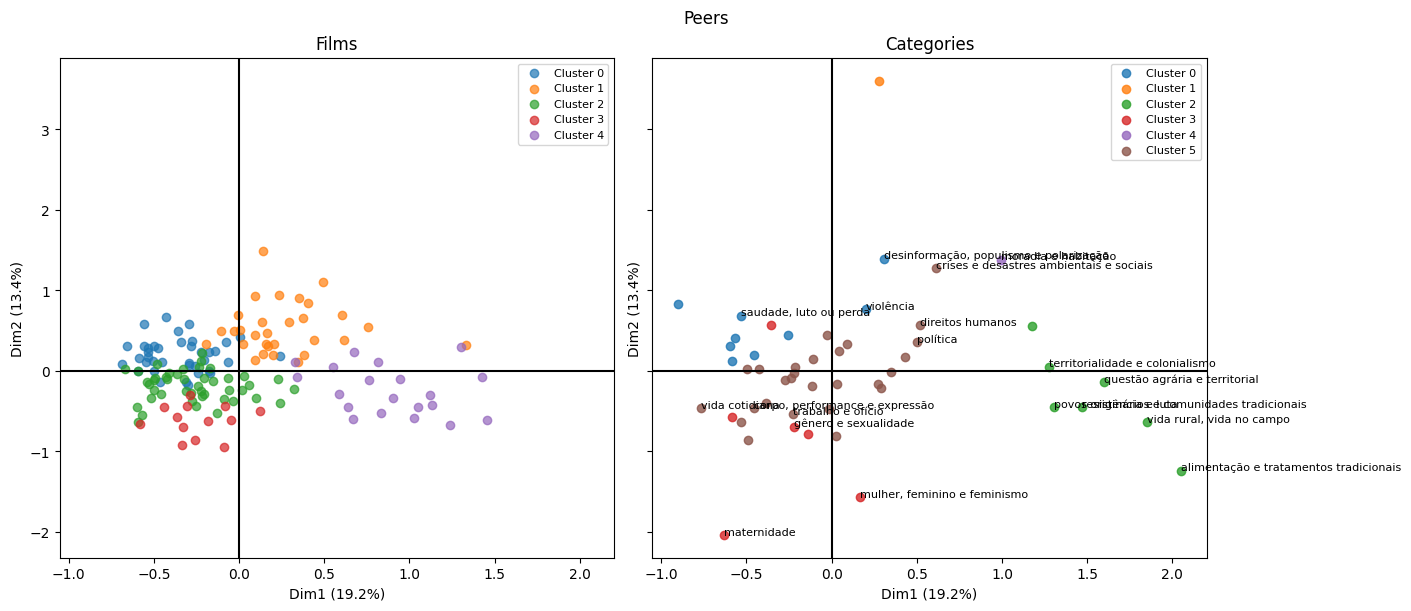

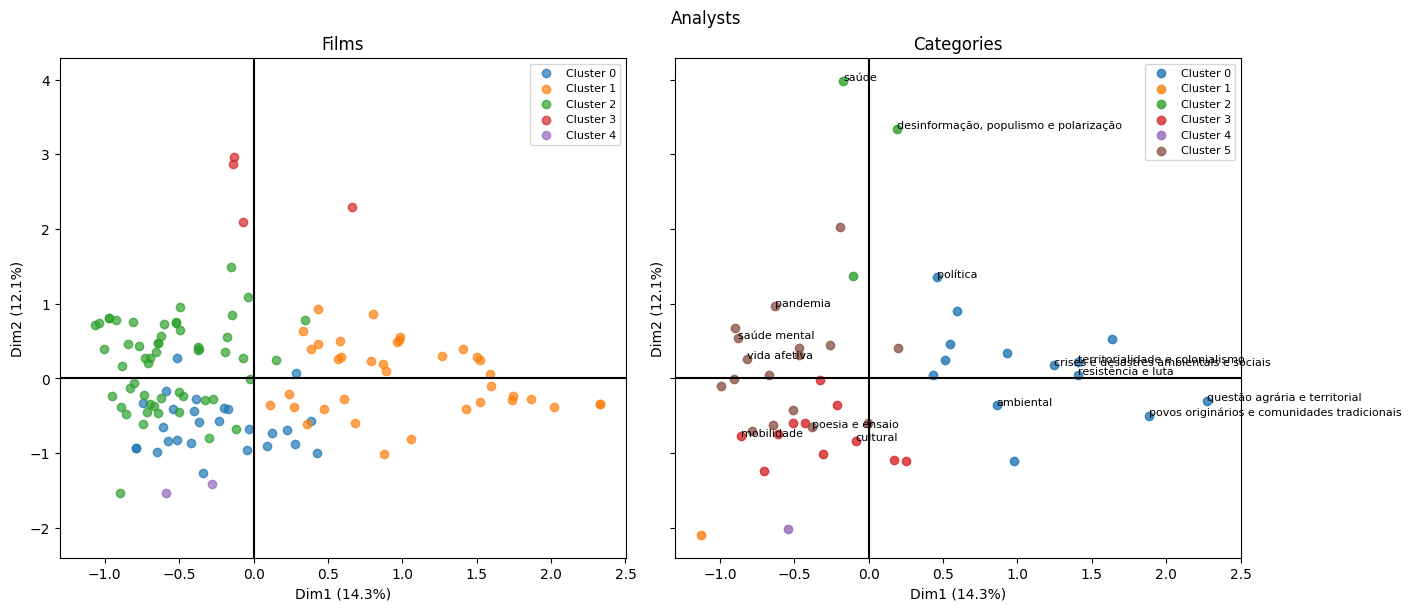

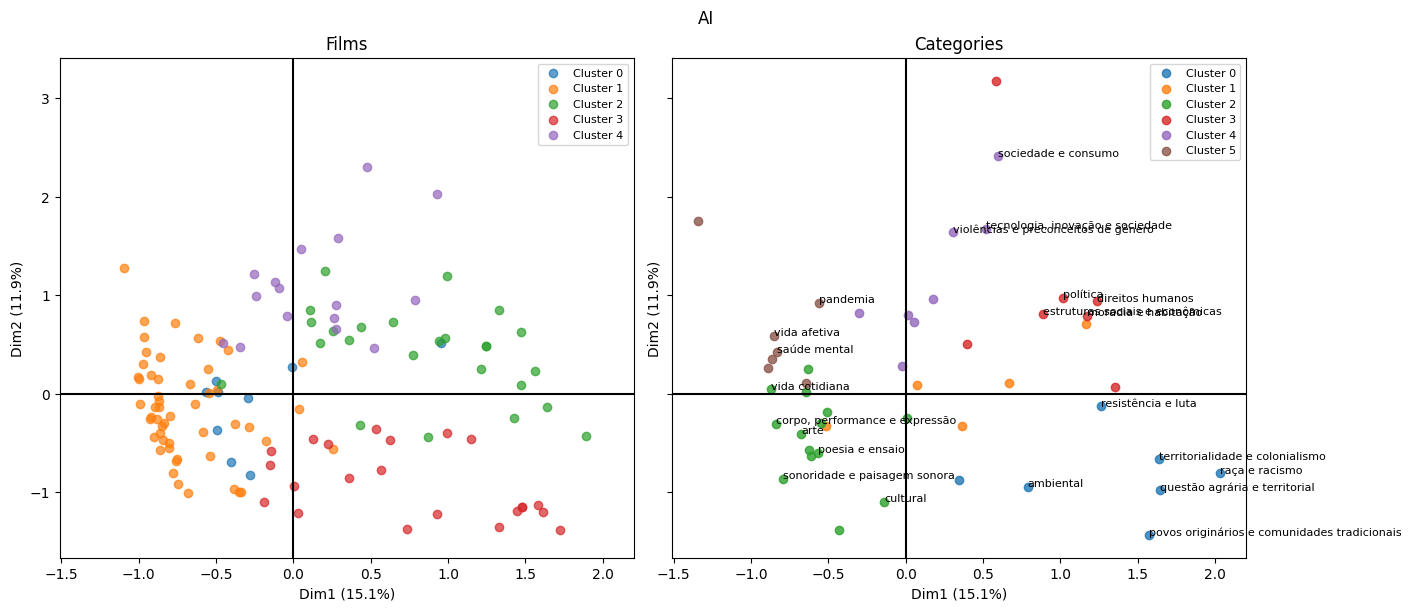

In [163]:
for dimension, df in dfs.items():

    X = engineering.get_binary_matrix(df, cats)

    X = X[X.columns[X.sum(axis=0) > 0]]
    X = X.astype(float)

    engineering.get_mca(X, dimension, df_titles, RESULTS_FIGURES_DIR)

## Identity Values

In [181]:
df_identities = pd.read_excel(f'{DATA_RAW_DIR}/Dados Identidades/Dados de Input Identidades/PAID_01_DadosParticipantes_Identidade.xlsx')

In [182]:
df_identities['film_id'] = df_identities['ID_OfGrPart'].str.split("-", n=1).str[0].str.strip().astype(int)
df_identities['rater_id'] = df_identities['ID_OfGrPart'].str.split("-", n=1).str[1].str.strip().astype(str)

df_identities = df_identities.set_index('ID_OfGrPart')

<div style="
    background-color: #77b6e9ff;
    border-left:6px solid #77b6e9ff;
    padding:12px;
    border-radius:4px;
    font-family: sans-serif;
">
<strong>Note</strong><br>
Films that are below ID 1069000 are removed from analysis
</div>

In [183]:
df_identities = df_identities[df_identities['film_id'] > 1069000]

In [184]:
df_identities.columns = df_identities.columns.str.replace(r"\s*\(.*?\)", "", regex=True).str.replace(r"[\[\]]", "", regex=True).str.strip()

### Correlation Analysis

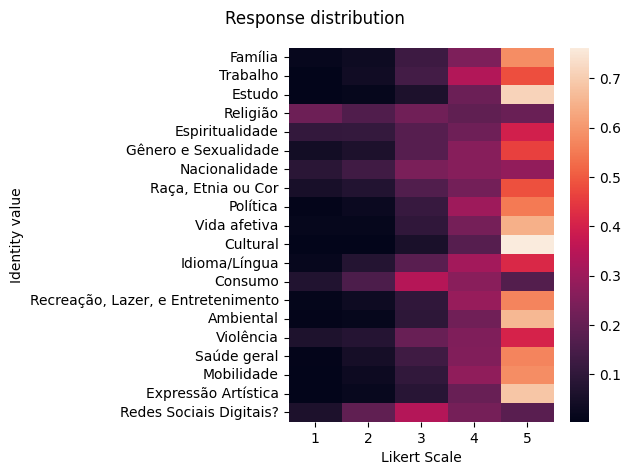

In [189]:
_df_identities = df_identities.drop(['film_id', 'rater_id'], axis = 1)

df_response_distributions = _df_identities.apply(lambda c: c.value_counts(normalize=True))

fig, ax = plt.subplots(1,1)
sns.heatmap(df_response_distributions.T, ax = ax)
ax.set_xlabel('Likert Scale')
ax.set_ylabel('Identity value')

fig.suptitle('Response distribution')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/identities_response_distribution.png', dpi = 300)

df_response_distributions.T.to_excel(f'{RESULTS_TABLES_DIR}/identities_response_distribution.xlsx')

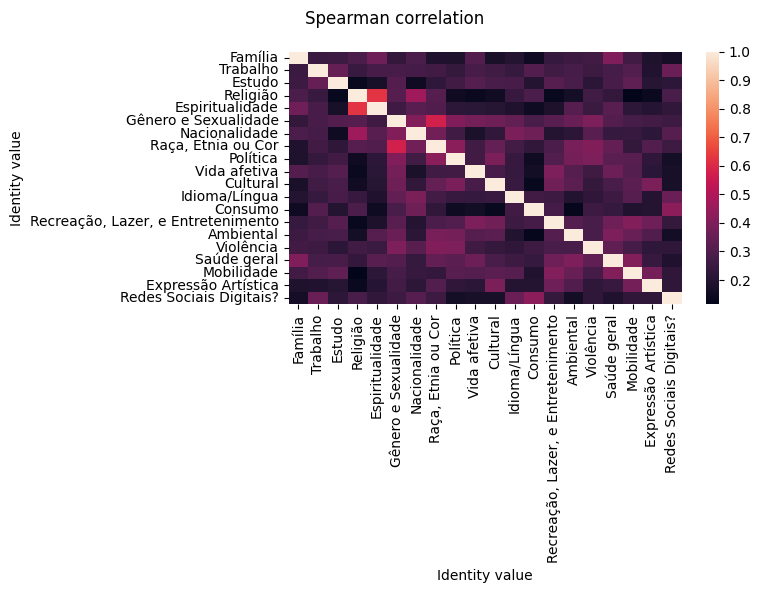

In [190]:
spearman_corr = _df_identities.corr(method='spearman')

fig, ax = plt.subplots(1,1, figsize=(8,6))
sns.heatmap(spearman_corr, ax = ax)
ax.set_xlabel('Identity value')
ax.set_ylabel('Identity value')

fig.suptitle('Spearman correlation')
fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/identities_spearman_correlation.png', dpi = 300)

spearman_corr.to_excel(f'{RESULTS_TABLES_DIR}/identities_spearman_correlation.xlsx')

### Latent Factor Analysis

In [192]:
def collapse_likert(x):
    return x.replace({1: 1, 2: 1, 3: 2, 4: 3, 5: 4})

df_ord = _df_identities.apply(collapse_likert)

df_ord.apply(lambda c: c.value_counts(normalize=True))

,Família,Trabalho,Estudo,Religião,Espiritualidade,Gênero e Sexualidade,Nacionalidade,"Raça, Etnia ou Cor",Política,Vida afetiva,Cultural,Idioma/Língua,Consumo,"Recreação, Lazer, e Entretenimento",Ambiental,Violência,Saúde geral,Mobilidade,Expressão Artística,Redes Sociais Digitais?
1,0.047359,0.043716,0.016393,0.377049,0.213115,0.102004,0.220401,0.123862,0.034608,0.027322,0.010929,0.092896,0.224044,0.043716,0.023679,0.142077,0.052823,0.034608,0.023679,0.251366
2,0.125683,0.138434,0.060109,0.222222,0.173042,0.173042,0.238616,0.163934,0.114754,0.098361,0.054645,0.180328,0.342441,0.098361,0.094718,0.205829,0.129326,0.103825,0.083789,0.338798
3,0.245902,0.336976,0.211293,0.191257,0.216758,0.264117,0.260474,0.227687,0.302368,0.231330,0.173042,0.309654,0.265938,0.289617,0.222222,0.247723,0.249545,0.278689,0.207650,0.231330
4,0.581056,0.480874,0.712204,0.209472,0.397086,0.460838,0.280510,0.484517,0.548270,0.642987,0.761384,0.417122,0.167577,0.568306,0.659381,0.404372,0.568306,0.582878,0.684882,0.178506


In [193]:
from factor_analyzer.factor_analyzer import calculate_kmo

# Kaiser-Meyer-Olkin shows if data is factorable. Values above 0.8 are good.

kmo_all, kmo_model = calculate_kmo(df_ord)
kmo_model

np.float64(0.8947999279153168)

In [194]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

chi2, p = calculate_bartlett_sphericity(df_ord)
p

np.float64(0.0)

In [195]:
_df_identities.to_csv(f'{RESULTS_DIR}/df_identities.csv')

In [218]:
from pathlib import Path
import subprocess

from DNAI.utils.paths import find_rscript_exe

R_SCRIPT = Path(PROJECT_ROOT, "src", "DNAI", "utils", "r_scripts", "polychoric.R")

RSCRIPT_EXE = find_rscript_exe()

subprocess.run([str(RSCRIPT_EXE), str(R_SCRIPT), str(RESULTS_DIR)], check=True)

CompletedProcess(args=['C:\\Program Files\\R\\R-4.5.2\\bin\\x64\\Rscript.exe', 'C:\\Users\\User01\\Documents\\Git\\DNAI\\src\\DNAI\\utils\\r_scripts\\polychoric.R', 'C:\\Users\\User01\\Documents\\Git\\DNAI\\results'], returncode=0)

In [219]:
R_poly = pd.read_csv(f'{RESULTS_DIR}/R_poly.csv', index_col = 0) #R_poly = polychoric correlation matrix. Calculated externally with R
R_poly.columns = _df_identities.columns
R_poly.index = _df_identities.columns

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



Text(0, 0.5, 'Eigenvalue')

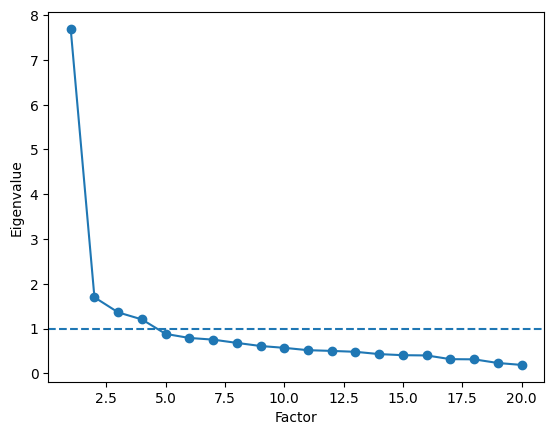

In [221]:
from factor_analyzer import FactorAnalyzer

fa_test = FactorAnalyzer(rotation=None, is_corr_matrix=True)
fa_test.fit(R_poly)

eigenvalues, _ = fa_test.get_eigenvalues()

plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker="o")
plt.axhline(1, linestyle="--")
plt.xlabel("Factor")
plt.ylabel("Eigenvalue")

In [252]:
k = len(eigenvalues[eigenvalues > 1])

fa = FactorAnalyzer(
    n_factors=k,
    rotation="oblimin",
    method="minres",
    is_corr_matrix=True
)

fa.fit(R_poly)

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



,n_factors,4
,rotation,'oblimin'
,method,'minres'
,use_smc,True
,is_corr_matrix,True
,bounds,"(0.005, ...)"
,impute,'median'
,svd_method,'randomized'
,rotation_kwargs,{}


In [231]:
loadings = pd.DataFrame(
    fa.loadings_,
    index=df_ord.columns,
    columns=[f"Factor{i+1}" for i in range(fa.n_factors)]
)

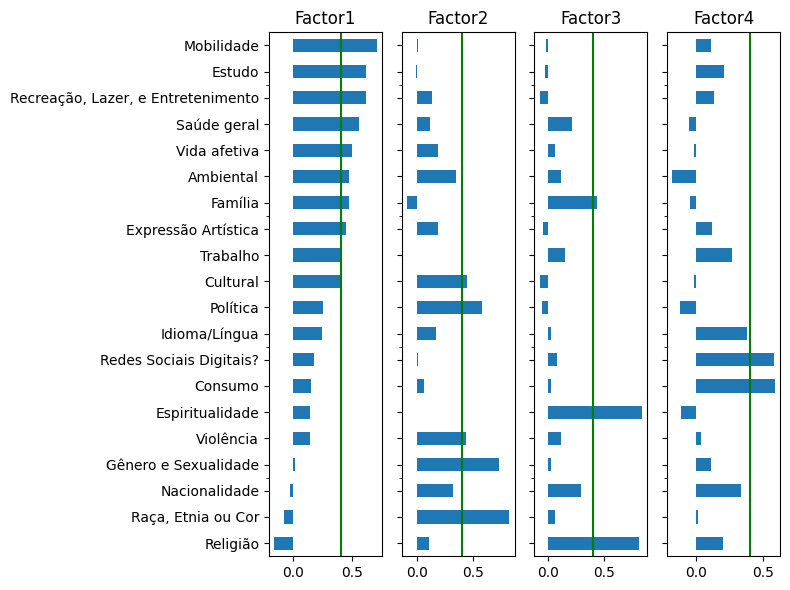

In [226]:
fig, axes = plt.subplots(1,k, sharey=True, figsize=(8,6))

loadings_sorted = loadings.sort_values(by='Factor1')

for col, ax in zip(loadings_sorted, axes.flat):
    loadings_sorted[col].plot(kind='barh', ax = ax)
    ax.axvline(0.4, color = 'green')
    ax.set_title(col)

fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/LFA.png', dpi = 300)

loadings_sorted.to_csv(f'{RESULTS_TABLES_DIR}/LFA.csv')
plt.show()

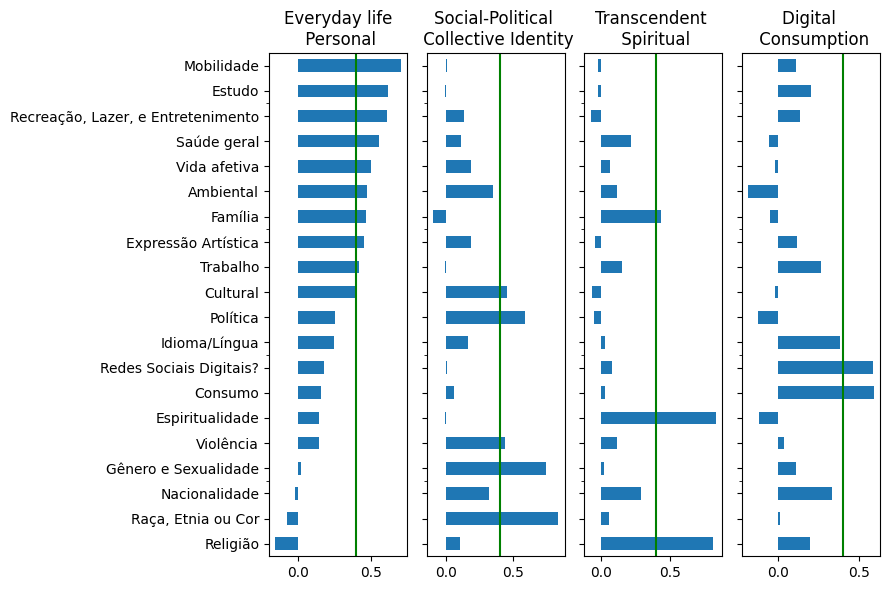

In [230]:
loadings_sorted_renamed = loadings_sorted.copy()
loadings_sorted_renamed.columns = ['Everyday life\n Personal', 'Social-Political \n Collective Identity', 'Transcendent \n Spiritual', 'Digital \n Consumption']

fig, axes = plt.subplots(1,k, sharey=True, figsize=(9,6))

for col, ax in zip(loadings_sorted_renamed, axes.flat):
    loadings_sorted_renamed[col].plot(kind='barh', ax = ax)
    ax.axvline(0.4, color = 'green')
    ax.set_title(col)

fig.tight_layout()
fig.savefig(f'{RESULTS_FIGURES_DIR}/LFA_names.png', dpi = 300)

loadings_sorted.to_csv(f'{RESULTS_TABLES_DIR}/LFA_names.csv')
plt.show()

In [233]:
problem_items = []

for item in loadings.index:
    vals = loadings.loc[item].abs()
    if (vals >= 0.30).sum() == 0:
        problem_items.append((item, "weak"))
    elif (vals >= 0.30).sum() > 1:
        problem_items.append((item, "cross-loading"))

problem_items

[('Família', 'cross-loading'),
 ('Nacionalidade', 'cross-loading'),
 ('Cultural', 'cross-loading'),
 ('Ambiental', 'cross-loading')]

* Cultural relates to everyday life and socio-political identity 
* Family relates to everyday life and Transcendent/Spiritual
* Ambiental relates to everyday life and social-political identity
* Language relates to everyday life and digital consumption

In [241]:
factor_scores = fa.transform(df_ord)

import pandas as pd

fs = pd.DataFrame(
    factor_scores,
    columns=[f"Factor{i+1}" for i in range(fa.n_factors)],
    index=df_ord.index
)

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\User01\Documents\Git\DNAI\.venv\Lib\site-packages\factor_analyzer\factor_analyzer.py:766: UserWarning:

Could not find original mean and standard deviation; usingthe mean and standard deviation from the current data set.



In [243]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
fs_scaled = scaler.fit_transform(fs)

fs_scaled = pd.DataFrame(
    fs_scaled,
    columns=fs.columns,
    index=fs.index
)

fs_scaled.to_csv(f'{RESULTS_TABLES_DIR}/LFA_factor_scores.csv')

<Axes: >

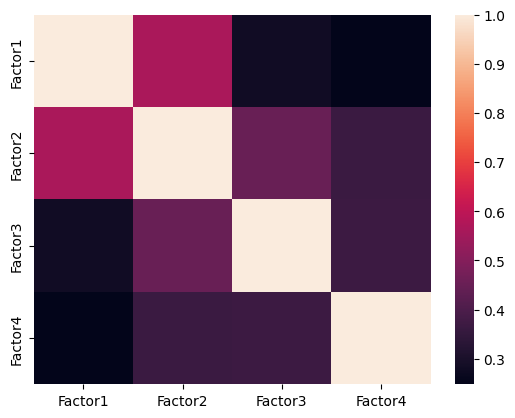

In [244]:
sns.heatmap(fs_scaled.corr())

### Clustering

In [238]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score

Z = linkage(fs_scaled, method="ward")

sil_scores = {}
for c in range(2, 8):
    labels = fcluster(Z, c, criterion="maxclust")
    sil_scores[c] = silhouette_score(fs_scaled, labels)

sil_scores

{2: 0.2427590373126028,
 3: 0.20011542716694772,
 4: 0.20055354625891925,
 5: 0.21042072778911547,
 6: 0.21436353988393803,
 7: 0.20244443951351868}

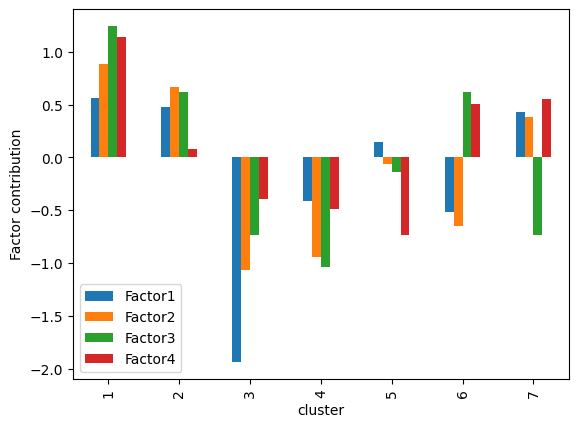

In [250]:
fs["cluster"] = fcluster(Z, c, criterion="maxclust")

cluster_profiles = fs.groupby("cluster").mean()

cluster_profiles.to_csv(f'{RESULTS_TABLES_DIR}/LFA_clusters.csv')

fig, ax = plt.subplots(1,1)
cluster_profiles.plot(kind='bar', ax = ax)
ax.set_ylabel('Factor contribution')

fig.savefig(f'{RESULTS_FIGURES_DIR}/LFA_clusters.png', dpi = 300)

* Cluster profiles have contributions from the 4 factors, indicating that identity profiles overlap. Forcing one subject to a particular cluster is not realistic, as there are no "pure" identity profiles. Instead, subjects belong to a soft continuum of identity profiles, which justifies the usage of soft clustering approaches.

<BarContainer object of 7 artists>

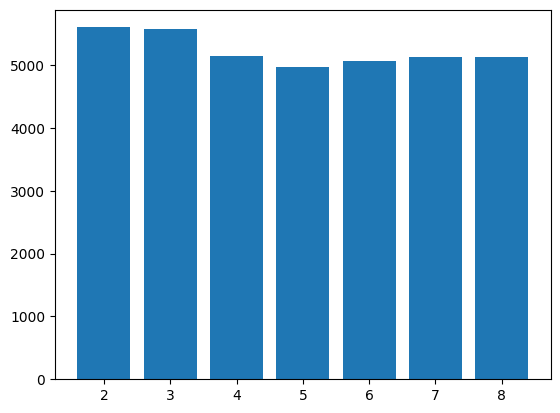

In [253]:
from sklearn.mixture import GaussianMixture

bic = {}
aic = {}

for c in range(2, 9):
    gmm = GaussianMixture(
        n_components=c,
        covariance_type="full",
        random_state=42
    )
    gmm.fit(fs_scaled)
    bic[c] = gmm.bic(fs_scaled)
    aic[c] = gmm.aic(fs_scaled)

bic, aic

plt.bar(bic.keys(), bic.values())

In [254]:
c_opt = min(bic, key = bic.get)

gmm = GaussianMixture(
    n_components=c_opt,
    covariance_type="full",
    random_state=42
)

gmm.fit(fs_scaled)

,n_components,5
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


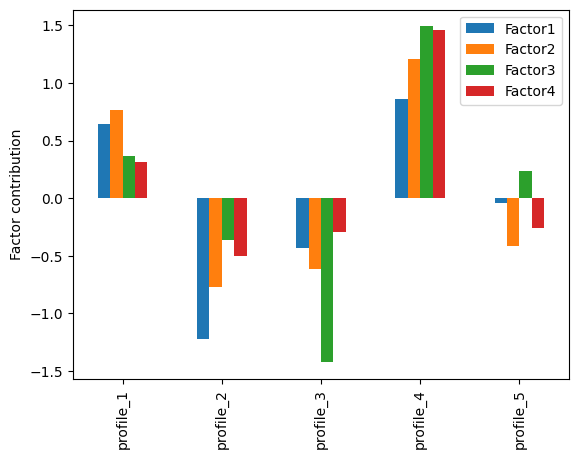

In [260]:
membership = pd.DataFrame(
    gmm.predict_proba(fs_scaled),
    columns=[f"profile_{i+1}" for i in range(c_opt)],
    index=fs_scaled.index
)

profile_means = pd.DataFrame(
    gmm.means_,
    columns=fs_scaled.columns,
    index=[f"profile_{i+1}" for i in range(c_opt)]
)

profile_means.to_csv(f'{RESULTS_TABLES_DIR}/LFA_gmm.csv')

fig, ax = plt.subplots(1,1)
profile_means.plot(kind='bar', ax = ax)
ax.set_ylabel('Factor contribution')

fig.savefig(f'{RESULTS_FIGURES_DIR}/LFA_gmm.png', dpi = 300)

In [261]:
hard_labels = gmm.predict(fs_scaled)

fs['cluster_gmm'] = hard_labels

### Identity cluster vs film category

In [262]:
membership_film = membership.copy()
membership_film['film_id'] = df_identities['film_id']

In [263]:
df_themes = df_authors_meso_wide.apply(lambda r: r.dropna().value_counts().head(3).index.tolist(), axis=1)

binary = (
    df_themes
    .apply(lambda x: x if isinstance(x, list) else [])
    .str.join("|")
    .str.get_dummies(sep="|")
)

df_themes_binary = binary.astype("int8")

In [271]:
#df_input = membership_film.reset_index(drop=False).merge(df_themes_binary.reset_index(drop=False), how='left', on = 'film_id')
#df_input.set_index('ID_OfGrPart', inplace = True)

In [272]:
freq = df_themes_binary.sum().sort_values()
freq

reflexão                                             1
moradia e habitação                                  1
sonho e fantasia                                     1
sistema penitenciário                                1
pessoas com deficiência                              2
solidão                                              2
arte                                                 2
resistência e luta                                   2
saúde                                                2
violências e preconceitos de gênero                  2
vida rural, vida no campo                            3
territorialidade e colonialismo                      3
nacionalidade e nacionalismo                         3
biografia                                            3
corpo, performance e expressão                       3
linguagem e representação                            3
vida cotidiana                                       3
violência                                            3
questão ag

In [273]:
cluster = membership.idxmax(axis=1)  # e.g., "profile_1", "profile_2", ...
cluster = cluster.astype("category")

cluster_counts = cluster.value_counts()
cluster_counts

profile_1    200
profile_5    158
profile_3     95
profile_2     62
profile_4     34
Name: count, dtype: int64

In [284]:
cluster

ID_OfGrPart
1070101-308    profile_3
1070101-316    profile_1
1070102-296    profile_5
1070102-301    profile_4
1070102-311    profile_5
                 ...    
1110133-212    profile_4
1110142-213    profile_5
1110145-216    profile_1
1110160-217    profile_1
1110159-218    profile_3
Length: 549, dtype: category
Categories (5, object): ['profile_1', 'profile_2', 'profile_3', 'profile_4', 'profile_5']

In [276]:
membership_film

,profile_1,profile_2,profile_3,profile_4,profile_5,film_id
ID_OfGrPart,,,,,,
1070101-308,1.738779e-09,9.444728e-02,8.939928e-01,0.000000,1.155988e-02,1070101
1070101-316,8.813894e-01,6.103985e-02,1.894217e-07,0.000000,5.757052e-02,1070101
1070102-296,3.046148e-08,1.041134e-02,1.169109e-52,0.000000,9.895886e-01,1070102
1070102-301,1.606214e-06,4.626503e-10,6.107449e-72,0.999998,1.551461e-09,1070102
1070102-311,6.986862e-08,2.381952e-01,1.655059e-12,0.000000,7.618047e-01,1070102
...,...,...,...,...,...,...
1110133-212,1.292901e-06,4.109923e-10,2.085708e-71,0.999999,1.262238e-09,1110133
1110142-213,1.819861e-02,3.845886e-03,4.532816e-69,0.000000,9.779555e-01,1110142
1110145-216,8.587131e-01,3.025284e-02,1.095434e-14,0.000000,1.110341e-01,1110145


In [326]:
from statsmodels.stats.multitest import multipletests

min_pos = 5
n_perm = 5000

rows = []
freq = df_themes_binary.sum()

for cat in df_themes_binary.columns:
    y = df_themes_binary[cat].astype(int)

    _y = (membership_film.reset_index().merge(y.reset_index(), on = 'film_id', how='left').set_index(membership_film.index.name))[cat]

    if y.sum() < min_pos:
        continue  # too sparse for meaningful inference

    chi2_obs, p = engineering.perm_chi2_pvalue(_y, cluster, n_perm=n_perm, seed=42)

    rows.append({
        "category": cat,
        "n_pos": int(y.sum()),
        "chi2": chi2_obs,
        "p": p
    })

omnibus = pd.DataFrame(rows).sort_values("p")

pvals = omnibus["p"].to_numpy()
reject, p_fdr, _, _ = multipletests(pvals, method="fdr_bh")

omnibus["p_fdr"] = p_fdr
omnibus["reject_fdr_0p05"] = reject

omnibus.sort_values("p_fdr")

omnibus.to_excel(f'{RESULTS_TABLES_DIR}/LFA_omnibus_clusters_gmm.xlsx')

omnibus


,category,n_pos,chi2,p,p_fdr,reject_fdr_0p05
12,pandemia,21,16.763452,0.002400,0.057588,False
2,crises e desastres ambientais e sociais,5,10.568041,0.032993,0.279544,False
18,saúde mental,12,10.154472,0.038192,0.279544,False
8,gênero e sexualidade,13,9.594755,0.046591,0.279544,False
19,sociedade e consumo,7,6.996821,0.142971,0.686263,False
5,"distopia, ficção científica e futuros imaginados",10,5.045013,0.270146,0.917816,False
10,mobilidade,6,4.945582,0.285943,0.917816,False
14,política,15,4.930763,0.305939,0.917816,False
9,memória e patrimônio,15,4.138371,0.392322,0.960244,False
7,estruturas sociais e econômicas,19,3.857070,0.413117,0.960244,False


In [297]:
def standardized_residuals_for_category(y_binary: pd.Series, cluster_labels: pd.Series):
    ct = pd.crosstab(cluster_labels, y_binary)
    if 0 not in ct.columns: ct[0] = 0
    if 1 not in ct.columns: ct[1] = 0
    ct = ct[[0, 1]]

    # expected counts from chi-square
    chi2, p, dof, expected = chi2_contingency(ct.values, correction=False)
    expected = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

    resid = (ct - expected) / np.sqrt(expected)
    return ct, resid

sig_cats = omnibus.loc[omnibus["reject_fdr_0p05"], "category"].tolist()
print(sig_cats)
for cat in sig_cats[:10]:
    ct, resid = standardized_residuals_for_category(df_themes_binary[cat].astype(int), cluster)
    print("\n", cat)
    print("Counts (cluster x {0,1}):")
    print(ct)
    print("Std residuals for presence (col=1):")
    print(resid[1].sort_values(ascending=False))


[]


* Cluster based approaches fail statistical tests.
    * Identity profiles are not well-separated
    * Discrete typologies are not supported
    * Identity is best treated dimensionally

Although participants produced multiple artworks, analyses were conducted at the participant level by aggregating thematic labels across artifacts. This approach avoids violations of independence while aligning with the study’s focus on identity as a subject-level construct. Results consistently indicated that latent identity dimensions did not show statistically detectable associations with specific thematic categories of artistic production.

### Factor level inference

#### Meso

In [325]:
fs_scaled_film = fs_scaled.copy()
fs_scaled_film['film_id'] = df_identities['film_id']

X = fs_scaled
Y = fs_scaled_film.reset_index().merge(df_themes_binary.reset_index(), on='film_id', how='left').set_index(fs_scaled_film.index.name)[df_themes_binary.columns]

Y = Y.dropna()

common_artifacts = X.index.intersection(Y.index)

X = X.loc[common_artifacts]
Y = Y.loc[common_artifacts]

feature_names = list(X.columns)

In [327]:
min_pos = 10
n_perm = 2000
C = 1.0

rows = []
freq = df_themes_binary.sum()

for cat in df_themes_binary.columns:
    y = Y[cat].astype(int).to_numpy()
    n_pos = int(y.sum())
    n_neg = int(len(y) - n_pos)

    # Skip categories that are too rare or degenerate
    if n_pos < min_pos or n_neg < min_pos:
        continue

    try:
        coefs_obs, stat_obs, p = engineering.perm_omnibus_pvalue(X, y, n_perm=n_perm, seed=42, C=C)
        rows.append({
            "category": cat,
            "n_pos": n_pos,
            "stat_max_abs_coef": stat_obs,
            "p_omnibus": p,
            **{f"coef_{fn}": c for fn, c in zip(feature_names, coefs_obs)}
        })
    except Exception as e:
        print(e)
        rows.append({
            "category": cat,
            "n_pos": n_pos,
            "stat_max_abs_coef": np.nan,
            "p_omnibus": np.nan,
            "error": str(e)
        })

omnibus = pd.DataFrame(rows)

if len(omnibus) == 0:
    print("No categories passed prevalence filters. Lower min_pos or aggregate themes further.")
else:
    reject, p_fdr, _, _ = multipletests(omnibus["p_omnibus"], method="fdr_bh")
    omnibus["p_fdr"] = p_fdr
    omnibus["reject_fdr_0p05"] = reject
    omnibus = omnibus.sort_values("p_fdr")

omnibus.to_excel(f'{RESULTS_TABLES_DIR}/LFA_omnibus_factors_meso.xlsx')
omnibus


,category,n_pos,stat_max_abs_coef,p_omnibus,coef_Factor1,coef_Factor2,coef_Factor3,coef_Factor4,p_fdr,reject_fdr_0p05
11,família,11,1.067650,0.007496,-0.802867,1.067650,-0.386629,0.333370,0.135932,False
20,política,49,0.536362,0.011994,-0.315512,0.313990,0.536362,-0.089115,0.135932,False
27,sociedade e consumo,21,0.786830,0.008996,0.211732,-0.786830,-0.086118,0.580362,0.135932,False
17,outros,56,0.482702,0.021989,0.150840,-0.140098,-0.482702,-0.018445,0.186907,False
22,questão agrária e territorial,13,0.846968,0.034983,-0.079757,-0.232418,0.846968,-0.234698,0.237881,False
24,"religião, espiritualidade e cosmologias",16,0.719258,0.053973,0.427661,-0.136618,0.719258,-0.166407,0.305847,False
10,estruturas sociais e econômicas,73,0.322219,0.121439,0.017091,0.060691,0.322219,-0.138116,0.455939,False
3,crises e desastres ambientais e sociais,17,0.566997,0.137931,-0.253062,0.566997,-0.169961,0.270409,0.455939,False
30,trabalho e ofício,30,0.429337,0.151424,0.176335,0.429337,-0.321673,0.004619,0.455939,False
29,"tecnologia, inovação e sociedade",17,0.587036,0.138931,0.459517,-0.587036,-0.103419,0.267987,0.455939,False


* There is no statistically detectable mapping between identity dimensions and specific film categories, given the observed sparsity and variability.

#### Macro

In [328]:
df_macro = pd.read_excel(f'{RESULTS_DIR}/Macrocategorias.xlsx')

In [329]:
macro = "Macro Categorias"
meso = "Categoria Original"


# 1. drop NaNs FIRST
df_map_clean = (
    df_macro[[meso, macro]]
    .dropna(subset=[meso, macro])
)

# 2. normalize meso keys (lowercase + strip)
df_map_clean["meso_norm"] = (
    df_map_clean[meso]
    .astype(str)
    .str.strip()
    .str.lower()
)

# 3. enforce one-to-many constraint (each meso → exactly one macro)
conflicts = (
    df_map_clean.groupby("meso_norm")[macro]
                .nunique()
                .loc[lambda s: s > 1]
)
if not conflicts.empty:
    raise ValueError(f"Meso mapped to multiple macros:\n{conflicts}")

# 4. build dictionary (values retain original macro casing)
meso_to_macro = (
    df_map_clean
    .drop_duplicates(subset=["meso_norm"])
    .set_index("meso_norm")[macro]
    .to_dict()
)

meso_to_macro

{'violência': '1) Saúde coletiva, segurança e crises',
 'saúde': '1) Saúde coletiva, segurança e crises',
 'pandemia': '1) Saúde coletiva, segurança e crises',
 'saúde mental': '1) Saúde coletiva, segurança e crises',
 'crises e desastres ambientais e sociais': '1) Saúde coletiva, segurança e crises',
 'ambiental': '2) Ambiente, território, urbano e habitação',
 'dinâmica urbana': '2) Ambiente, território, urbano e habitação',
 'mobilidade': '2) Ambiente, território, urbano e habitação',
 'questão agrária e territorial': '2) Ambiente, território, urbano e habitação',
 'vida rural, vida no campo': '2) Ambiente, território, urbano e habitação',
 'moradia e habitação': '2) Ambiente, território, urbano e habitação',
 'trabalho e ofício': '3) Economia, trabalho e consumo',
 'estruturas sociais e econômicas': '3) Economia, trabalho e consumo',
 'sociedade e consumo': '3) Economia, trabalho e consumo',
 'política': '4) Política, justiça, direitos e conflitos',
 'nacionalidade e nacionalismo':

In [330]:
df_authors_macro_wide = df_authors_meso_wide.apply(lambda col: col.map(meso_to_macro))

In [ ]:
df_themes_macro = df_authors_macro_wide.apply(lambda r: r.dropna().value_counts().head(3).index.tolist(), axis=1)

binary = (
    df_themes_macro
    .apply(lambda x: x if isinstance(x, list) else [])
    .str.join("|")
    .str.get_dummies(sep="|")
)

df_themes_macro_binary = binary.astype("int8")

In [332]:
df_themes_macro_binary.index = df_themes_macro_binary.index.astype(int)

In [333]:
X = fs_scaled
Y = fs_scaled_film.reset_index().merge(df_themes_macro_binary.reset_index(), on='film_id', how='left').set_index(fs_scaled_film.index.name)[df_themes_macro_binary.columns]

Y = Y.dropna()

common_artifacts = X.index.intersection(Y.index)

X = X.loc[common_artifacts]
Y = Y.loc[common_artifacts]

feature_names = list(X.columns)

In [336]:
min_pos = 10
n_perm = 2000
C = 1.0

rows = []
freq = df_themes_macro_binary.sum()

for cat in df_themes_macro_binary.columns:
    y = Y[cat].astype(int).to_numpy()
    n_pos = int(y.sum())
    n_neg = int(len(y) - n_pos)

    # Skip categories that are too rare or degenerate
    if n_pos < min_pos or n_neg < min_pos:
        continue

    try:
        coefs_obs, stat_obs, p = engineering.perm_omnibus_pvalue(X, y, n_perm=n_perm, seed=42, C=C)
        rows.append({
            "category": cat,
            "n_pos": n_pos,
            "stat_max_abs_coef": stat_obs,
            "p_omnibus": p,
            **{f"coef_{fn}": c for fn, c in zip(feature_names, coefs_obs)}
        })
    except Exception as e:
        print(e)
        rows.append({
            "category": cat,
            "n_pos": n_pos,
            "stat_max_abs_coef": np.nan,
            "p_omnibus": np.nan,
            "error": str(e)
        })

omnibus = pd.DataFrame(rows) #.dropna(subset=["p_omnibus"]).sort_values("p_omnibus")

if len(omnibus) == 0:
    print("No categories passed prevalence filters. Lower min_pos or aggregate themes further.")
else:
    reject, p_fdr, _, _ = multipletests(omnibus["p_omnibus"], method="fdr_bh")
    omnibus["p_fdr"] = p_fdr
    omnibus["reject_fdr_0p05"] = reject
    omnibus = omnibus.sort_values("p_fdr")

omnibus.to_excel(f'{RESULTS_TABLES_DIR}/LFA_omnibus_factors_macro.xlsx')
omnibus

,category,n_pos,stat_max_abs_coef,p_omnibus,coef_Factor1,coef_Factor2,coef_Factor3,coef_Factor4,p_fdr,reject_fdr_0p05
0,"1) Saúde coletiva, segurança e crises",139,0.385222,0.004998,-0.067423,0.079478,-0.385222,0.091596,0.054973,False
1,10) Expressões simbólicas e narrativas pessoais,26,0.619705,0.032484,0.062750,0.329985,-0.619705,-0.302430,0.089330,False
3,20) Outros,53,0.467291,0.031484,0.074015,-0.057241,-0.467291,-0.121285,0.089330,False
5,"4) Política, justiça, direitos e conflitos",84,0.378568,0.032484,-0.378568,0.235266,0.350363,0.086599,0.089330,False
4,"3) Economia, trabalho e consumo",158,0.226823,0.146927,0.210514,-0.219442,0.226823,0.009096,0.323238,False
9,"8) Vida privada, afetos e cotidiano",275,0.192523,0.208396,0.021680,-0.020951,0.033601,-0.192523,0.382059,False
2,"2) Ambiente, território, urbano e habitação",206,0.186068,0.284858,0.024992,-0.076784,0.186068,0.015257,0.447633,False
7,"6) Tecnologia, mídia e futuros imaginados",84,0.197032,0.467266,0.197032,-0.119784,-0.152332,0.035863,0.642491,False
8,"7) Identidades, corpo e marcadores sociais",113,0.163822,0.544228,-0.134160,0.145740,0.163822,0.060565,0.665167,False
10,"9) Espiritualidade, luto e reflexão",71,0.161005,0.674163,-0.013228,0.011011,-0.105794,0.161005,0.741579,False


## Machine Learning

In [337]:
import xgboost as xgb

def make_model(scale_pos_weight):
    return xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=1200,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=2.0,
        min_child_weight=2,
        gamma=0.0,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )

### Factors

In [361]:
_fs = fs.drop(['cluster', 'cluster_gmm'], axis = 1).copy()
_fs["film_id"] = _fs.index.str.split("-", n=1).str[0].astype(int)
_fs["rater_id"] = _fs.index.str.split("-", n=1).str[1].astype(int)

df_input_ml = _fs.reset_index(drop=False).merge(df_themes_binary.reset_index(drop=False), on='film_id', how='inner')
df_input_ml.set_index('ID_OfGrPart', inplace=True)

In [421]:
pattern = df_input_ml.columns.str.contains('Factor')

X = df_input_ml.loc[:, pattern]
Y = df_input_ml.loc[:, ~pattern].drop(['film_id', 'rater_id'], axis = 1)

label_names = df_input_ml.columns[~pattern].drop(['film_id', 'rater_id'])

In [422]:
from sklearn.model_selection import GroupKFold

groups = df_input_ml['rater_id']
cv = GroupKFold(n_splits=5)

In [423]:
from sklearn.metrics import f1_score

Y_true_all = []
Y_pred_all = []
models = []

for train_idx, val_idx in cv.split(X, Y, groups=groups):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    Y_train, Y_val = Y.iloc[train_idx], Y.iloc[val_idx]

    Y_pred = np.zeros_like(Y_val, dtype=float)

    for j, label in enumerate(label_names):
        y_tr = Y_train.iloc[:, j]
        y_va = Y_val.iloc[:, j]

        # skip labels with no positives in training
        if y_tr.sum() == 0:
            continue

        pos = y_tr.sum()
        neg = len(y_tr) - pos
        scale_pos_weight = neg / pos

        model = make_model(scale_pos_weight)
        model.fit(X_train, y_tr)

        models.append(model)

        Y_pred[:, j] = model.predict_proba(X_val)[:, 1]

    Y_true_all.append(Y_val)
    Y_pred_all.append(Y_pred)

Y_true = np.vstack(Y_true_all)
Y_pred = np.vstack(Y_pred_all)

#### Evaluation

In [424]:
from sklearn.metrics import precision_recall_curve

thresholds = []

for j in range(Y_true.shape[1]):
    precision, recall, th = precision_recall_curve(
        Y_true[:, j], Y_pred[:, j]
    )
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    thresholds.append(th[np.argmax(f1)])


In [425]:
Y_pred_bin = (Y_pred >= thresholds).astype(int)


In [367]:
from sklearn.metrics import f1_score, jaccard_score

print("Micro F1:", f1_score(Y_true, Y_pred_bin, average="micro"))
print("Macro F1:", f1_score(Y_true, Y_pred_bin, average="macro"))
print("Jaccard :", jaccard_score(Y_true, Y_pred_bin, average="samples"))


Micro F1: 0.17880462079357107
Macro F1: 0.1445435558133466
Jaccard : 0.10032154233377744


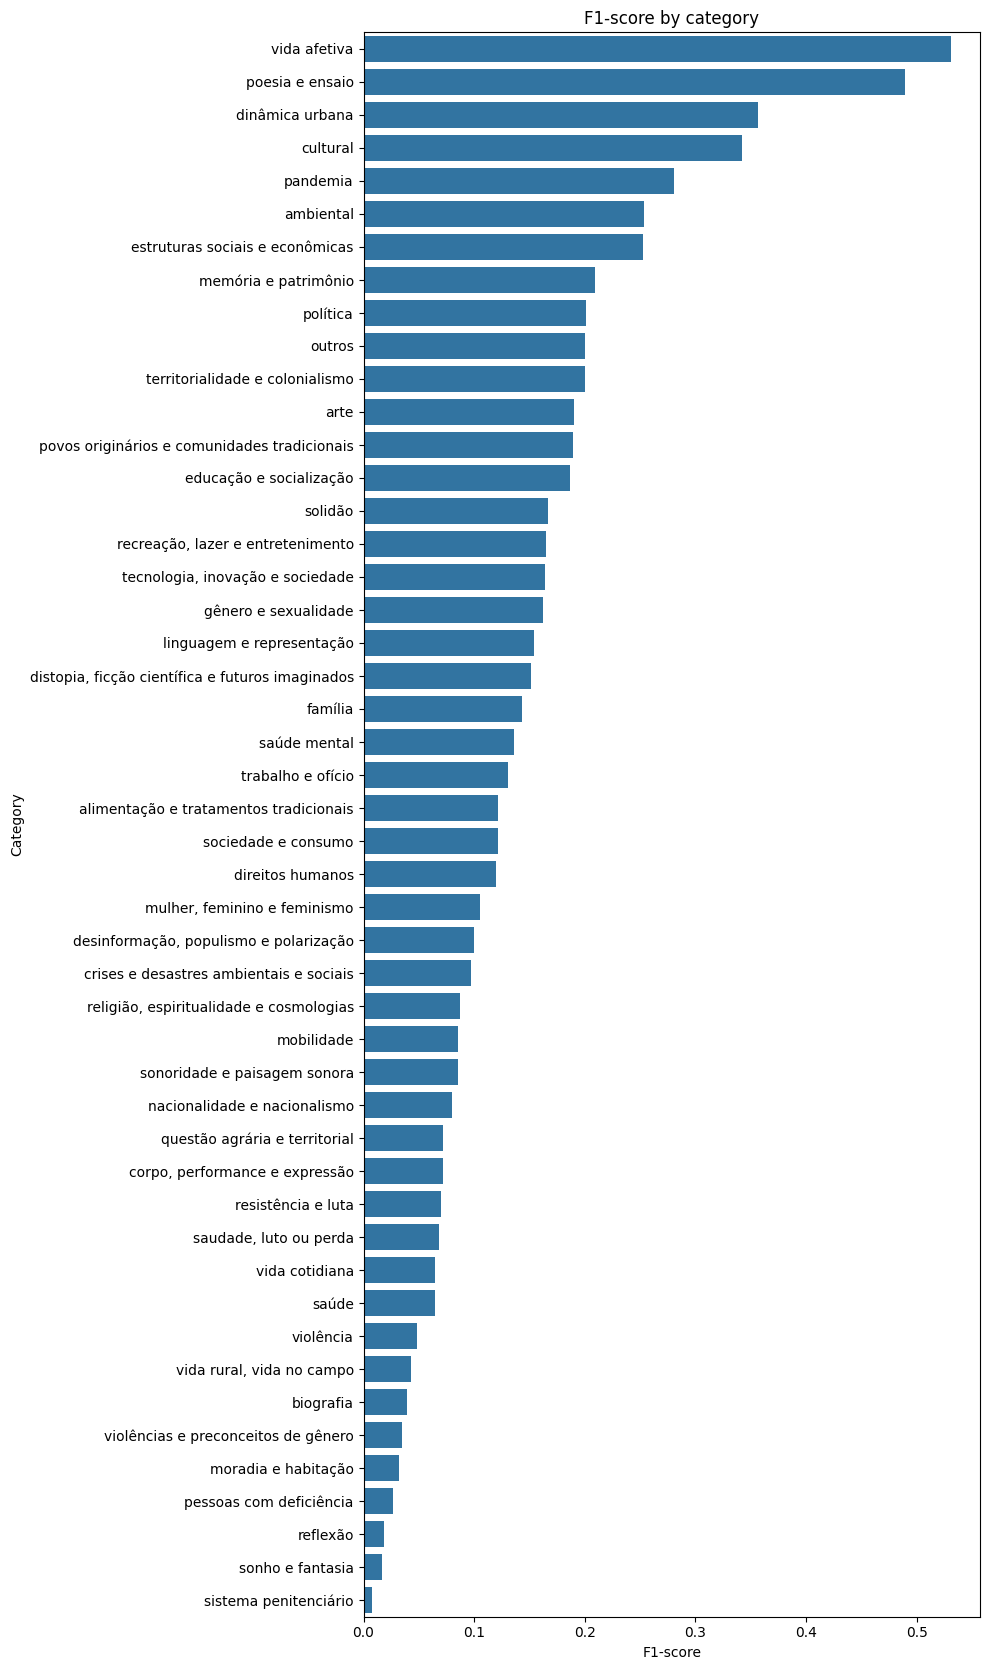

In [426]:
df_f1 = pd.DataFrame({
    "label": label_names,
    "f1": [f1_score(Y_true[:, j], Y_pred_bin[:, j], zero_division=0)
           for j in range(Y_true.shape[1])],
    "prevalence": [Y_true[:, j].mean() for j in range(Y_true.shape[1])]  # fraction of films with label
}).sort_values("f1", ascending=False)

plt.figure(figsize=(10, max(6, 0.35 * len(df_f1))))
sns.barplot(data=df_f1, x="f1", y="label")
plt.title("F1-score by category")
plt.xlabel("F1-score")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(f'{RESULTS_FIGURES_DIR}/xgboost_f1_score_factors.png', dpi= 300)
plt.show()

In [369]:
df_f1.to_excel(f'{RESULTS_TABLES_DIR}/xgboost_f1_score_factors.xlsx')

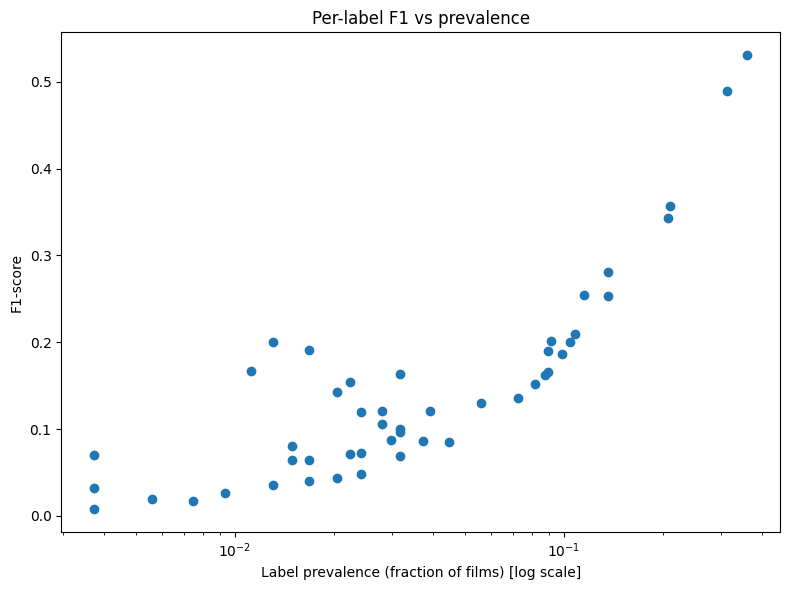

In [370]:

plt.figure(figsize=(8, 6))
plt.scatter(df_f1["prevalence"], df_f1["f1"])
plt.xscale("log")  # labels often long-tail; log makes this readable
plt.xlabel("Label prevalence (fraction of films) [log scale]")
plt.ylabel("F1-score")
plt.title("Per-label F1 vs prevalence")
plt.tight_layout()
plt.show()

In [371]:
import shap

mean_abs_per_label = []

for model in models:
    explainer = shap.TreeExplainer(model)
    X_explain = X
    sv = explainer.shap_values(X_explain)  # (n_samples, n_features)
    mean_abs_per_label.append(np.abs(sv).mean(axis=0))

# Average global importance across labels
global_importance = np.mean(mean_abs_per_label, axis=0)

imp = pd.Series(global_importance, index=X_explain.columns).sort_values()

In [372]:
imp.to_excel(f'{RESULTS_TABLES_DIR}/xgoobst_shap_factors.xlsx')

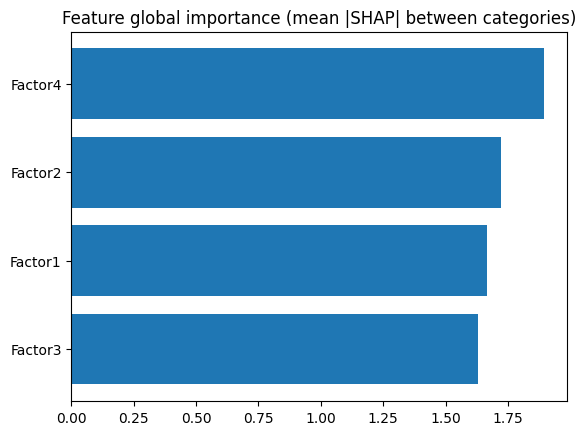

In [374]:
imp = pd.Series(global_importance, index=X_explain.columns).sort_values()
plt.figure()
plt.barh(imp.index, imp.values)
plt.title("Feature global importance (mean |SHAP| between categories)")
#plt.tight_layout()
plt.savefig(f'{RESULTS_FIGURES_DIR}/xgboost_shap_factors.png', bbox_inches="tight", dpi = 300)
plt.show()

In [376]:
df_f1

,label,f1,prevalence
43,vida afetiva,0.530780,0.361266
24,poesia e ensaio,0.489256,0.312849
8,dinâmica urbana,0.356557,0.210428
6,cultural,0.342593,0.206704
22,pandemia,0.281046,0.135940
1,ambiental,0.253968,0.115456
12,estruturas sociais e econômicas,0.252788,0.135940
16,memória e patrimônio,0.209184,0.108007
25,política,0.201313,0.091248
21,outros,0.200000,0.104283


In [377]:
from sklearn.metrics import classification_report

print(classification_report(Y_true, Y_pred_bin, target_names=label_names))


                                                  precision    recall  f1-score   support

          alimentação e tratamentos tradicionais       0.08      0.27      0.12        15
                                       ambiental       0.17      0.52      0.25        62
                                            arte       0.17      0.22      0.19         9
                                       biografia       0.02      1.00      0.04         9
                  corpo, performance e expressão       0.05      0.17      0.07        12
         crises e desastres ambientais e sociais       0.07      0.18      0.10        17
                                        cultural       0.21      1.00      0.34       111
          desinformação, populismo e polarização       0.09      0.12      0.10        17
                                 dinâmica urbana       0.23      0.77      0.36       113
                                direitos humanos       0.07      0.31      0.12        13
distopia,

In [378]:
report = classification_report(
    Y_true,
    Y_pred_bin,
    target_names=label_names,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report.to_excel(f'{RESULTS_TABLES_DIR}/xgboost_report_factors.xlsx')

### Likert

In [379]:
df_themes_list = []

for theme in column_themes:

    df_theme = df_authors_meso_wide.xs(theme, axis = 1, level = -1)

    list_themes = df_theme.apply(lambda row : row.dropna().unique(), axis = 1)

    list_themes.name = theme

    df_themes_list.append(list_themes)

df_themes = pd.concat(df_themes_list, axis = 1)

In [380]:
from collections import Counter

label_cols = ['Tema 0', 'Tema 2', 'Tema 3']

def to_list(x):
    # Treat missing as empty
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    # If it's already a list/tuple/set, make it a list
    if isinstance(x, (list, tuple, set)):
        return list(x)
    # If it's a numpy array, convert safely
    if isinstance(x, np.ndarray):
        return x.tolist()
    # If it's a scalar (e.g., a single label), wrap it
    return [x]

def top3_row(row):
    labels = []
    for c in label_cols:
        labels.extend(to_list(row[c]))
    return [lab for lab, _ in Counter(labels).most_common(3)]

df_themes["top_3_themes"] = df_themes.apply(top3_row, axis=1)

In [401]:
X = df_identities.copy().drop(['film_id', 'rater_id'], axis = 1)

Y = df_identities.reset_index().merge(df_themes, on = 'film_id', how='left').set_index(df_identities.index.name)['Tema 0']
Y = Y.dropna()
common_artifacts = X.index.intersection(Y.index)

X = X.loc[common_artifacts]
Y = Y.loc[common_artifacts]


In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(Y)
label_names = mlb.classes_

In [404]:
groups = df_identities.loc[common_artifacts, 'rater_id']
cv = GroupKFold(n_splits=5)

In [405]:
from sklearn.metrics import f1_score

Y_true_all = []
Y_pred_all = []
models = []

for train_idx, val_idx in cv.split(X, Y, groups=groups):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    Y_train, Y_val = Y[train_idx], Y[val_idx]

    Y_pred = np.zeros_like(Y_val, dtype=float)

    for j, label in enumerate(label_names):
        y_tr = Y_train[:, j]
        y_va = Y_val[:, j]

        # skip labels with no positives in training
        if y_tr.sum() == 0:
            continue

        pos = y_tr.sum()
        neg = len(y_tr) - pos
        scale_pos_weight = neg / pos

        model = make_model(scale_pos_weight)
        model.fit(X_train, y_tr)

        models.append(model)

        Y_pred[:, j] = model.predict_proba(X_val)[:, 1]

    Y_true_all.append(Y_val)
    Y_pred_all.append(Y_pred)

Y_true = np.vstack(Y_true_all)
Y_pred = np.vstack(Y_pred_all)


#### Evaluation

In [406]:
from sklearn.metrics import precision_recall_curve

thresholds = []

for j in range(Y_true.shape[1]):
    precision, recall, th = precision_recall_curve(
        Y_true[:, j], Y_pred[:, j]
    )
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    thresholds.append(th[np.argmax(f1)])


In [407]:
Y_pred_bin = (Y_pred >= thresholds).astype(int)


In [408]:
from sklearn.metrics import f1_score, jaccard_score

print("Micro F1:", f1_score(Y_true, Y_pred_bin, average="micro"))
print("Macro F1:", f1_score(Y_true, Y_pred_bin, average="macro"))
print("Jaccard :", jaccard_score(Y_true, Y_pred_bin, average="samples"))


Micro F1: 0.19355264025314786
Macro F1: 0.1642872501050535
Jaccard : 0.10817139625044513


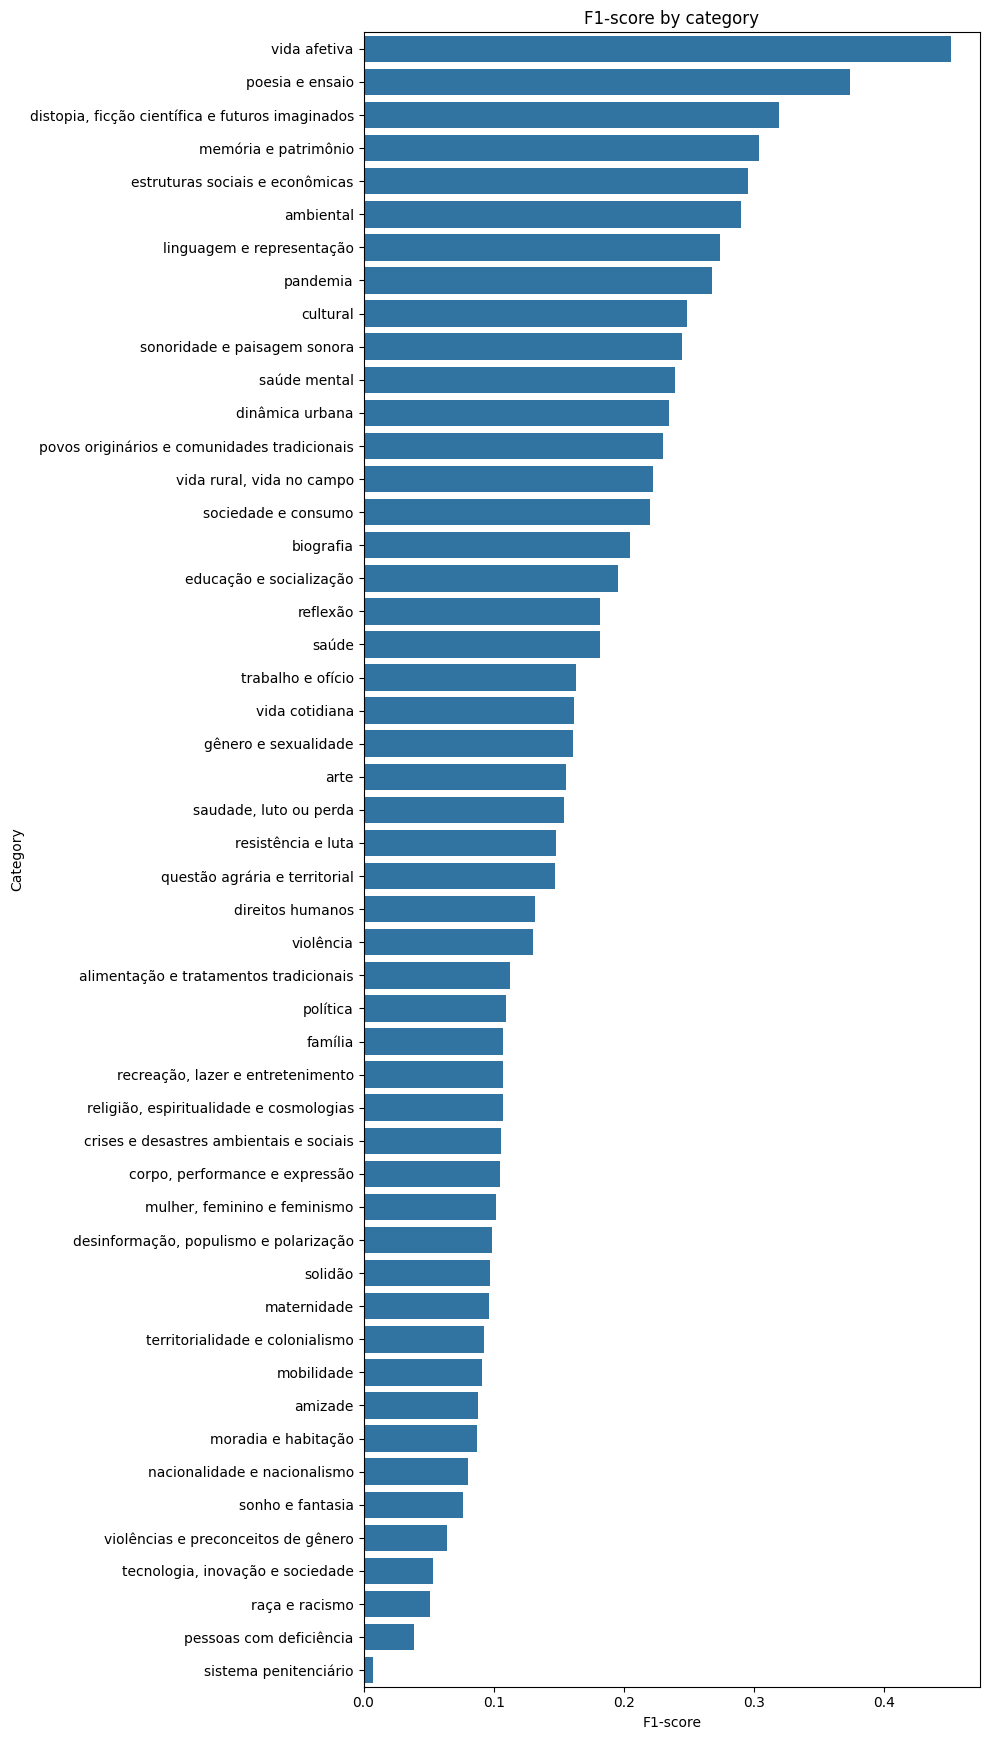

In [420]:
df_f1 = pd.DataFrame({
    "label": label_names,
    "f1": [f1_score(Y_true[:, j], Y_pred_bin[:, j], zero_division=0)
           for j in range(Y_true.shape[1])],
    "prevalence": [Y_true[:, j].mean() for j in range(Y_true.shape[1])]  # fraction of films with label
}).sort_values("f1", ascending=False)

plt.figure(figsize=(10, max(6, 0.35 * len(df_f1))))
sns.barplot(data=df_f1, x="f1", y="label")
plt.title("F1-score by category")
plt.xlabel("F1-score")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(f'{RESULTS_FIGURES_DIR}/xgboost_f1_score_likert.png', dpi= 300)
plt.show()

In [410]:
df_f1.to_excel(f'{RESULTS_TABLES_DIR}/xgboost_f1_score_likert.xlsx')

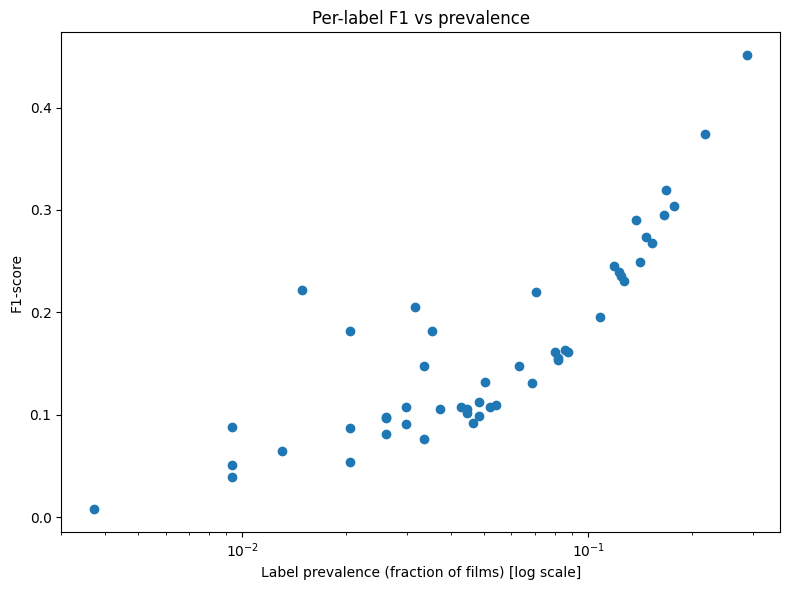

In [411]:

plt.figure(figsize=(8, 6))
plt.scatter(df_f1["prevalence"], df_f1["f1"])
plt.xscale("log")  # labels often long-tail; log makes this readable
plt.xlabel("Label prevalence (fraction of films) [log scale]")
plt.ylabel("F1-score")
plt.title("Per-label F1 vs prevalence")
plt.tight_layout()
plt.show()

In [412]:
import shap

mean_abs_per_label = []

for model in models:
    explainer = shap.TreeExplainer(model)
    X_explain = X
    sv = explainer.shap_values(X_explain)  # (n_samples, n_features)
    mean_abs_per_label.append(np.abs(sv).mean(axis=0))

# Average global importance across labels
global_importance = np.mean(mean_abs_per_label, axis=0)

imp = pd.Series(global_importance, index=X_explain.columns).sort_values()

In [413]:
imp.to_excel(f'{RESULTS_TABLES_DIR}/xgoobst_shap_likert.xlsx')

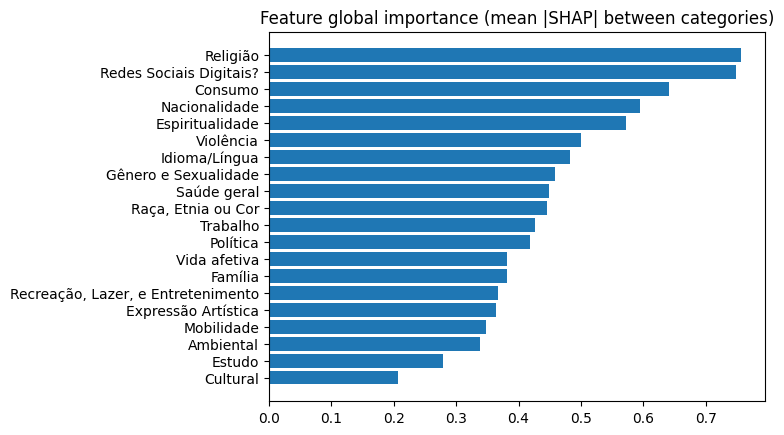

In [414]:
imp = pd.Series(global_importance, index=X_explain.columns).sort_values()
plt.figure()
plt.barh(imp.index, imp.values)
plt.title("Feature global importance (mean |SHAP| between categories)")
#plt.tight_layout()
plt.savefig(f'{RESULTS_FIGURES_DIR}/xgboost_shap_likert.png', bbox_inches="tight", dpi = 300)
plt.show()

In [415]:
df_f1

,label,f1,prevalence
45,vida afetiva,0.451237,0.288641
25,poesia e ensaio,0.374101,0.217877
11,"distopia, ficção científica e futuros imaginados",0.319527,0.167598
18,memória e patrimônio,0.303716,0.176909
13,estruturas sociais e econômicas,0.295139,0.165736
1,ambiental,0.290456,0.137803
16,linguagem e representação,0.273885,0.147114
23,pandemia,0.268132,0.152700
7,cultural,0.248773,0.141527
41,sonoridade e paisagem sonora,0.245125,0.119181


In [416]:
from sklearn.metrics import classification_report

print(classification_report(Y_true, Y_pred_bin, target_names=label_names))


                                                  precision    recall  f1-score   support

          alimentação e tratamentos tradicionais       0.06      0.50      0.11        26
                                       ambiental       0.21      0.47      0.29        74
                                         amizade       0.05      0.60      0.09         5
                                            arte       0.10      0.32      0.16        44
                                       biografia       0.18      0.24      0.21        17
                  corpo, performance e expressão       0.14      0.08      0.11        24
         crises e desastres ambientais e sociais       0.06      0.80      0.11        20
                                        cultural       0.14      1.00      0.25        76
          desinformação, populismo e polarização       0.05      0.62      0.10        26
                                 dinâmica urbana       0.13      1.00      0.24        67
         

In [417]:
report = classification_report(
    Y_true,
    Y_pred_bin,
    target_names=label_names,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report.to_excel(f'{RESULTS_TABLES_DIR}/xgboost_report_likert.xlsx')